# 🚀 SAIR PyTorch Mastery - Lecture 8B: HuggingFace FineTuning

**Course:** Applied Deep Learning with PyTorch  
**Module:** Sequence & NLP  
**Instructor:** Mohammed Awad Ahmed (Silva)  
**SAIR Community:** Building Sudan's AI Future 🇸🇩

---

## Welcome to Fine-tuning

In Lecture 8A you learned to *use* HuggingFace models. Today you learn to *own* them.

Fine-tuning takes a model that already understands language and adapts it to your
specific task, domain, and language. It is the single highest-leverage skill in
practical NLP.

### Where You Are

```
Module 3: Sequence & NLP
    |-- Lecture 6: Many-to-One      (LSTM classifier from scratch)
    |-- Lecture 7: Many-to-Many     (text generator from scratch)
    |-- Lecture 8A: HF Ecosystem    (used pretrained models)
    |-- Lecture 8B: Fine-tuning  <- YOU ARE HERE
    `-- (Next): Transformers from Scratch
```

### What You Will Master Today

**Concepts:** Why fine-tuning beats zero-shot | what changes during fine-tuning | transfer learning intuition

**Three Fine-tuning Pipelines:**
- DistilBERT (encoder) on IMDB sentiment
- GPT-2 (decoder) on SMS Spam — a generation model becomes a classifier
- AraBERT (Arabic encoder) on real Arabic sentiment data

**The Core Insight:** Same 50 lines of Trainer API code. Three completely different architectures.
One pipeline to rule them all.

**Production Skills:** Save/load models | push to Hub | deploy as pipeline | write model card

**Time Commitment:** 3-4 hours for full understanding

---

# Setup

Run this cell first. On Colab with GPU it takes about 60 seconds.

In [2]:
# suppress noisy warnings before anything loads
import transformers as _tr_pre
_tr_pre.logging.set_verbosity_error()

In [3]:
get_ipython().system('pip install transformers datasets evaluate accelerate scikit-learn seaborn -q')
print('Libraries installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00
Libraries installed


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, time, collections, random
warnings.filterwarnings('ignore')

import transformers as _tr
_tr.logging.set_verbosity_error()

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
from datasets import load_dataset, Dataset, DatasetDict
import evaluate
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('All imports loaded')
print(f'Device      : {device}')
print(f'PyTorch     : {torch.__version__}')
print(f'Transformers: {_tr.__version__}')

if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print('GPU ready - training will be fast')
else:
    print('No GPU detected.')
    print('Fix: Runtime -> Change runtime type -> T4 GPU')

All imports loaded
Device      : cuda
PyTorch     : 2.10.0+cu128
Transformers: 5.0.0
GPU  : Tesla T4
VRAM : 15.6 GB
GPU ready - training will be fast


---

# PART 0: The Bridge - Why Fine-tune?

You already have `pipeline('sentiment-analysis')` from Lecture 8A. So why fine-tune?

The answer: **domain gap** - the difference between what the pretrained model learned
and what your specific task requires.

## The Three Tiers of NLP Deployment

```
TIER 1: Zero-Shot
  Code: 3 lines | Data: None | Time: Minutes
  Accuracy (general English) : 85-90%
  Accuracy (Sudanese dialect): 55-65%  <- domain gap hurts
  Best for: Prototypes, no training data

TIER 2: Fine-tuning  (THIS LECTURE)
  Code: ~50 lines | Data: 1k-10k labeled | Time: 30min-2hr (GPU)
  Accuracy (general English) : 93-96%
  Accuracy (Sudanese dialect): 88-92%  <- domain gap closed
  Best for: Production systems, domain-specific tasks

TIER 3: Training from Scratch
  Code: 300+ lines | Data: 100k+ | Time: Hours to days
  Best for: Unique architectures, new languages, research
```

In [5]:
general_classifier = pipeline('sentiment-analysis')

domain_examples = [
    ('the product is amazing and quality is excellent',
     'General positive', 'POSITIVE'),
    ('this thing is completely useless and broken',
     'General negative', 'NEGATIVE'),
    ('The latency is through the roof but throughput is sick',
     'Tech jargon (high latency=bad, sick throughput=good)', 'MIXED'),
    ('Oh great, another update that broke everything.',
     'Sarcastic negative', 'NEGATIVE'),
    ('side effects manageable and efficacy was remarkable',
     'Medical domain positive', 'POSITIVE'),
]

print('=' * 65)
print('ZERO-SHOT PERFORMANCE ON DOMAIN-SPECIFIC TEXT')
print('=' * 65)
print(f'{"Description":<45} {"Expected":<10} {"Got":<10} {"Conf"}')
print('-' * 75)

correct = 0
for text, description, expected in domain_examples:
    result = general_classifier(text[:200])[0]
    got    = result['label']
    conf   = result['score']
    match  = 'OK' if got == expected else 'WRONG'
    if got == expected:
        correct += 1
    print(f'{match} {description[:43]:<43} {expected:<10} {got:<10} {conf:.3f}')

print(f'\nZero-shot accuracy: {correct}/{len(domain_examples)}')
print('Fine-tuning on domain data would push this to 4-5/5.')

del general_classifier

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

ZERO-SHOT PERFORMANCE ON DOMAIN-SPECIFIC TEXT
Description                                   Expected   Got        Conf
---------------------------------------------------------------------------
OK General positive                            POSITIVE   POSITIVE   1.000
OK General negative                            NEGATIVE   NEGATIVE   1.000
WRONG Tech jargon (high latency=bad, sick through MIXED      NEGATIVE   0.999
WRONG Sarcastic negative                          NEGATIVE   POSITIVE   1.000
OK Medical domain positive                     POSITIVE   POSITIVE   1.000

Zero-shot accuracy: 3/5
Fine-tuning on domain data would push this to 4-5/5.


---

# PART 1: The Fine-tuning Mental Model

## 1.1 Your Lecture 5 Training Loop vs The Trainer API

```python
# ============================================================
# YOUR LECTURE 5 train_model()  |  TRAINER EQUIVALENT
# ============================================================

model = model.to(device)        # -> handled by TrainingArguments
criterion = nn.CrossEntropyLoss # -> built into Trainer
optimizer = optim.Adam(lr=0.001)# -> TrainingArguments(learning_rate=2e-5)
scheduler = ReduceLROnPlateau() # -> lr_scheduler_type='linear'
                                #    warmup_ratio=0.1
for epoch in range(epochs):     # -> num_train_epochs=3
  for batch in train_loader:    # -> per_device_train_batch_size=16
    optimizer.zero_grad()       # -> handled internally
    loss.backward()             # -> handled internally
    clip_grad_norm_(m, 1.0)     # -> max_grad_norm=1.0
  # Validation loop             # -> eval_strategy='epoch'
  # Save best model             # -> load_best_model_at_end=True
# ============================================================
# YOUR 60-LINE FUNCTION  =  TrainingArguments + Trainer
# ============================================================
```

## 1.2 What Actually Changes During Fine-tuning

```
BERT during fine-tuning:

  Input: [CLS] I loved this movie [SEP]
       |
  [Embedding Layer]   <- UPDATED (small nudges)
       |
  [Transformer x12]   <- UPDATED (small nudges, higher layers more)
       |
  [CLS] token  <-- position 0, designed to aggregate whole sequence
       |
  [Classification Head 768->2]  <- NEW randomly initialized weights
       |
  [POSITIVE / NEGATIVE]

Key insight:
  66M pretrained parameters -> small gradient updates (lr=2e-5)
  ~1,538 new parameters (head) -> trained from scratch
  Large lr = catastrophic forgetting of pretrained knowledge
```

## 1.3 Model Selection Guide

```
MODEL SELECTION - Speed vs Accuracy

Model                        Params  Speed  Accuracy  Best for
------------------------------------------------------------------
distilbert-base-uncased       66M    *****   ***     Prototypes, CPU
bert-base-uncased            110M    ****    ****    Standard tasks
bert-large-uncased           340M    **      *****   Max accuracy
roberta-base                 125M    ****    ****    Best base model
gpt2                         124M    ****    ****    Decoder fine-tuning

For Arabic:
  aubmindlab/bert-base-arabertv2            -> best general Arabic
  CAMeL-Lab/bert-base-arabic-camelbert-da  -> best for dialects
  UBC-NLP/MARBERT                          -> best for social media
```

In [6]:
MODEL_NAME = 'distilbert-base-uncased'
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

total_params      = sum(p.numel() for p in model.parameters())
pretrained_params = sum(p.numel() for n, p in model.named_parameters()
                        if 'classifier' not in n)
new_params        = sum(p.numel() for n, p in model.named_parameters()
                        if 'classifier' in n)

print('MODEL ANATOMY BEFORE FINE-TUNING')
print('=' * 50)
print(f'Total parameters      : {total_params:,}')
print(f'Pretrained (backbone) : {pretrained_params:,}  <- from pretraining')
print(f'New (classifier head) : {new_params:,}  <- randomly initialized')
print(f'\nClassifier head: {model.classifier}')
print(f'Label mapping  : {model.config.id2label}')
print('\nFine-tuning nudges ALL weights slightly (lr=2e-5)')
print('Large lr would erase pretrained knowledge (catastrophic forgetting)')

del model

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

MODEL ANATOMY BEFORE FINE-TUNING
Total parameters      : 66,955,010
Pretrained (backbone) : 66,362,880  <- from pretraining
New (classifier head) : 592,130  <- randomly initialized

Classifier head: Linear(in_features=768, out_features=2, bias=True)
Label mapping  : {0: 'LABEL_0', 1: 'LABEL_1'}

Fine-tuning nudges ALL weights slightly (lr=2e-5)
Large lr would erase pretrained knowledge (catastrophic forgetting)


---

# PART 2: Data Preparation

```
Raw dataset
    |  load_dataset()           <- you know this from 8A
Labeled examples
    |  tokenizer + map()        <- you know this from 8A
Tokenized tensors
    |  DataCollatorWithPadding  <- replaces your collate_batch()
Training-ready batches
    |  Trainer                  <- replaces your train_model()
Fine-tuned model
```

In [7]:
print('Loading IMDB dataset...')
raw_dataset = load_dataset('imdb')

print(f'Train size : {len(raw_dataset["train"]):,}')
print(f'Test size  : {len(raw_dataset["test"]):,}')

train_labels = Counter(raw_dataset['train']['label'])
for label_id, count in sorted(train_labels.items()):
    name = raw_dataset['train'].features['label'].names[label_id]
    print(f'  {label_id} ({name:8}): {count:,}')

ex = raw_dataset['train'][0]
label_name = raw_dataset['train'].features['label'].names[ex['label']]
print(f'\nExample (label={label_name}): {ex["text"][:150]}...')

Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size : 25,000
Test size  : 25,000
  0 (neg     ): 12,500
  1 (pos     ): 12,500

Example (label=neg): I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th...


In [8]:
# Adjust sizes based on hardware:
# CPU only: TRAIN_SIZE=1000, VAL_SIZE=250, TEST_SIZE=250
# Colab T4 GPU: TRAIN_SIZE=5000, VAL_SIZE=1000, TEST_SIZE=1000

TRAIN_SIZE = 3000
VAL_SIZE   = 750
TEST_SIZE  = 750

train_full = raw_dataset['train'].shuffle(seed=42)
test_full  = raw_dataset['test'].shuffle(seed=42)
train_val  = train_full.train_test_split(
    test_size=VAL_SIZE / (TRAIN_SIZE + VAL_SIZE), seed=42
)

dataset = {
    'train' : train_val['train'].select(range(TRAIN_SIZE)),
    'val'   : train_val['test'].select(range(VAL_SIZE)),
    'test'  : test_full.select(range(TEST_SIZE)),
}

for split, data in dataset.items():
    labels = Counter(data['label'])
    print(f'{split:5}: {len(data):,} examples  pos={labels[1]}, neg={labels[0]}')

train: 3,000 examples  pos=1524, neg=1476
val  : 750 examples  pos=355, neg=395
test : 750 examples  pos=362, neg=388


## 2.1 Class Imbalance Check

Real datasets are rarely 50/50. Detecting imbalance early saves you from chasing
phantom accuracy numbers. A model that always predicts the majority class
can get 95% accuracy while being completely useless.

In [9]:
label_counts = Counter(dataset['train']['label'])
majority = max(label_counts.values())
minority = min(label_counts.values())
ratio    = majority / minority

print('CLASS IMBALANCE CHECK')
print('=' * 50)
for label_id, count in sorted(label_counts.items()):
    bar  = '#' * int(count / majority * 30)
    pct  = count / sum(label_counts.values()) * 100
    name = raw_dataset['train'].features['label'].names[label_id]
    print(f'  {label_id} ({name:8}): {count:5,}  {bar}  ({pct:.1f}%)')

print(f'\nImbalance ratio: {ratio:.2f}:1  ', end='')

if ratio > 5:
    print('SEVERE imbalance')
    print('  Actions: oversample minority | use weighted loss | report F1 not accuracy')
elif ratio > 2:
    print('MODERATE imbalance')
    print('  Recommended: use F1 as primary metric')
else:
    print('BALANCED - no action needed')

print('\nNOTE: IMDB is balanced. Your real-world data will often NOT be.')
print('Run this check at the start of every new project.')

CLASS IMBALANCE CHECK
  0 (neg     ): 1,476  #############################  (49.2%)
  1 (pos     ): 1,524  ##############################  (50.8%)

Imbalance ratio: 1.03:1  BALANCED - no action needed

NOTE: IMDB is balanced. Your real-world data will often NOT be.
Run this check at the start of every new project.


### 2.2 Tokenization

Text strings cannot go into a model. We convert them to integer IDs using the
model's vocabulary. Two rules to remember:

- **No padding here** — we pass `truncation=True` but no `padding`. Padding happens
  later in the DataCollator, per batch. Padding now would waste memory.
- **`remove_columns=['text']`** — once tokenized, the raw text column is redundant.
  Keeping it forces the model to load string data it cannot use. Remove it.

`map(batched=True)` processes examples in chunks and caches the result on disk.
For 3,000 examples trained across 3 epochs, tokenization runs **once** total —
not 9,000 times as it would in a Lecture 5 `__getitem__()` loop.

In [10]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer : {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

def tokenize_function(examples):
    # NO padding here — DataCollatorWithPadding handles it per batch
    # Padding to 512 globally wastes 60-90% of each tensor as zeros
    return tokenizer(examples['text'], truncation=True, max_length=512)

print('Tokenizing all splits...')
tokenized = {
    split: data.map(
        tokenize_function,
        batched=True,
        remove_columns=['text'],
        desc=f'Tokenizing {split}'
    )
    for split, data in dataset.items()
}

print(f'Features: {list(tokenized["train"].features.keys())}')
ex = tokenized['train'][0]
print(f'First example: {len(ex["input_ids"])} tokens, label={ex["label"]}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer : distilbert-base-uncased
Vocab size: 30,522
Tokenizing all splits...


Tokenizing train:   0%|          | 0/3000 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/750 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/750 [00:00<?, ? examples/s]

Features: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
First example: 216 tokens, label=1


### 2.3 Dynamic Padding with DataCollatorWithPadding

Tokenization is done — every example now has `input_ids` and `attention_mask`.
But sequences in a batch must all be the same length for matrix operations.

The naive fix is to pad every sequence to 512 tokens. Bad idea: a batch where
the longest review is 94 tokens would have 418 wasted columns of zeros per row.
That is 80% waste on every forward and backward pass.

`DataCollatorWithPadding` pads to the **longest sequence in each batch** instead.
Different batches get different shapes. The cell below shows this concretely —
watch the padding numbers change depending on which examples land in the batch.

In [11]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized['train'][i] for i in range(4)]
print('Raw sequences (variable lengths):')
for i, ex in enumerate(sample_batch):
    print(f'  Example {i}: {len(ex["input_ids"]):3d} tokens  label={ex["label"]}')

collated = data_collator(sample_batch)
max_len  = collated['input_ids'].shape[1]
print(f'\nAfter collation (padded to batch maximum = {max_len}):')
print(f'  input_ids shape: {collated["input_ids"].shape}')
for i in range(4):
    mask       = collated['attention_mask'][i].tolist()
    real_count = sum(mask)
    print(f'  Example {i}: {real_count} real + {max_len-real_count} padding')

print('\nLecture 5 equivalent: your collate_batch() using pad_sequence()')
print('DataCollatorWithPadding does the same + handles multiple tensor types')

Raw sequences (variable lengths):
  Example 0: 216 tokens  label=1
  Example 1: 262 tokens  label=1
  Example 2: 148 tokens  label=1
  Example 3: 310 tokens  label=0

After collation (padded to batch maximum = 310):
  input_ids shape: torch.Size([4, 310])
  Example 0: 216 real + 94 padding
  Example 1: 262 real + 48 padding
  Example 2: 148 real + 162 padding
  Example 3: 310 real + 0 padding

Lecture 5 equivalent: your collate_batch() using pad_sequence()
DataCollatorWithPadding does the same + handles multiple tensor types


### STOP AND THINK

1. `map()` tokenizes once and caches. For 3,000 examples x 3 epochs, how many tokenizer
   calls does `map()` make vs your Lecture 5 `__getitem__()` approach?

2. We used `remove_columns=['text']`. Why is it important to remove raw text before training?

3. DataCollator pads to the longest sequence in each batch. For a batch where the longest
   review is 94 tokens, what is the `input_ids` shape? Compare to padding everything to 512.

4. The model has `num_labels=2`. Trainer uses CrossEntropyLoss automatically.
   What would you change for 5 sentiment classes?

---

# PART 3: Fine-tuning DistilBERT (Encoder) on IMDB

```
TrainingArguments    <- all hyperparameters in one object
      +
Trainer              <- wraps model + data + args + metrics
      |
trainer.train()      <- one call, full training loop
```

In [12]:
accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)['accuracy']
    f1  = f1_metric.compute(predictions=predictions, references=labels, average='binary')['f1']
    return {'accuracy': acc, 'f1': f1}

# quick sanity check
FakeEvalPred = collections.namedtuple('EvalPred', ['predictions', 'label_ids'])
fake = FakeEvalPred(
    np.array([[2.1, 0.3], [0.1, 3.5], [1.8, 0.2], [0.4, 2.9]]),
    np.array([0, 1, 0, 1])
)
print(f'compute_metrics test: {compute_metrics(fake)}')
print('compute_metrics works correctly')

compute_metrics test: {'accuracy': 1.0, 'f1': 1.0}
compute_metrics works correctly


### 3.1 TrainingArguments — Every Hyperparameter in One Place

`TrainingArguments` is the equivalent of every configuration decision you made
manually in Lecture 5: learning rate, epochs, batch size, scheduler, gradient
clipping, evaluation frequency, checkpoint saving. All in one object.

Two arguments here that are new and important:

- **`warmup_ratio=0.1`** — for the first 10% of training steps, the learning rate
  ramps up from 0 to `2e-5` instead of starting at full speed. Necessary because
  the classification head starts with random weights; large gradients from it
  could corrupt the pretrained backbone before it has a chance to adapt.

- **`load_best_model_at_end=True`** — after training, the Trainer automatically
  restores the checkpoint with the best validation accuracy. Without this, you
  would deploy whichever checkpoint happened to be last — which may be overfit.

The cell also plots the learning rate schedule so you can see warmup visually.

Epochs        : 3
Batch size    : 16
Learning rate : 2e-05
Total steps   : ~561
Warmup steps  : ~56


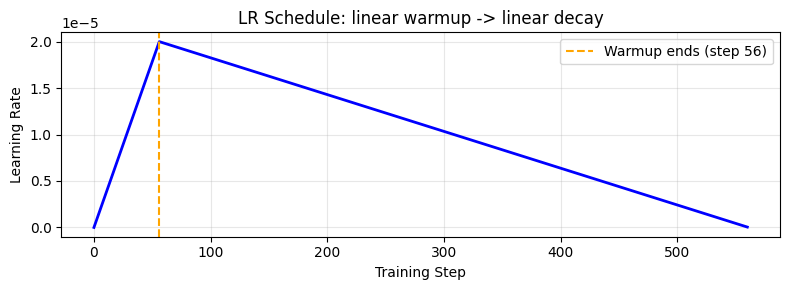

Why warmup matters:
  At step 0 the classification head has RANDOM weights.
  Full lr=2e-5 immediately sends large gradients through all 66M params.
  Warmup lets the random head stabilise first.


In [13]:
training_args = TrainingArguments(
    output_dir='./results/imdb-distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,           # 50x smaller than your L5 lr=0.001
    lr_scheduler_type='linear',
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=42,
)

steps_per_epoch = TRAIN_SIZE // training_args.per_device_train_batch_size
total_steps     = steps_per_epoch * training_args.num_train_epochs
warmup_steps    = int(total_steps * training_args.warmup_ratio)

print(f'Epochs        : {training_args.num_train_epochs}')
print(f'Batch size    : {training_args.per_device_train_batch_size}')
print(f'Learning rate : {training_args.learning_rate}')
print(f'Total steps   : ~{total_steps}')
print(f'Warmup steps  : ~{warmup_steps}')

# visualise LR schedule
steps    = np.arange(total_steps)
lr_sched = []
for s in steps:
    if s < warmup_steps:
        lr_sched.append(training_args.learning_rate * s / warmup_steps)
    else:
        decay = (total_steps - s) / max(1, total_steps - warmup_steps)
        lr_sched.append(training_args.learning_rate * decay)

plt.figure(figsize=(8, 3))
plt.plot(steps, lr_sched, 'b-', linewidth=2)
plt.axvline(x=warmup_steps, color='orange', linestyle='--',
            label=f'Warmup ends (step {warmup_steps})')
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('LR Schedule: linear warmup -> linear decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Why warmup matters:')
print('  At step 0 the classification head has RANDOM weights.')
print('  Full lr=2e-5 immediately sends large gradients through all 66M params.')
print('  Warmup lets the random head stabilise first.')

### 3.2 The `make_trainer` Helper

This function handles one API change between Transformers versions: the `tokenizer`
argument was renamed to `processing_class` in version 4.46. Rather than breaking
on old or new installs, `make_trainer` tries the new name first and falls back
gracefully. You do not need to modify it — just call it the same way every time.

In [14]:
def make_trainer(model, args, train_ds, eval_ds, tokenizer, collator, metrics_fn):
    """Version-safe Trainer factory. tokenizer was renamed processing_class in 4.46+"""
    shared = dict(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=eval_ds,
        data_collator=collator, compute_metrics=metrics_fn,
    )
    try:
        return _tr.Trainer(**shared, processing_class=tokenizer)
    except TypeError:
        return _tr.Trainer(**shared, tokenizer=tokenizer)

## 3.2 Assemble the Trainer

Everything is ready. We now load a fresh model and hand it to the Trainer.
Notice the variable name: `distilbert_model` — not just `model`. This matters
because Parts 5 and 6 will load `gpt2_model` and `arabic_model` in the same
session. Keeping distinct names means all three models stay in memory for the
final comparison in Part 7.

In [15]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
    label2id={'NEGATIVE': 0, 'POSITIVE': 1},
)

distilbert_trainer = make_trainer(
    model=distilbert_model,
    args=training_args,
    train_ds=tokenized['train'],
    eval_ds=tokenized['val'],
    tokenizer=tokenizer,
    collator=data_collator,
    metrics_fn=compute_metrics,
)

print(f'Model      : {MODEL_NAME}')
print(f'Parameters : {sum(p.numel() for p in distilbert_model.parameters()):,}')
print(f'Train size : {len(tokenized["train"]):,}')
print('Ready. Call distilbert_trainer.train() to start.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model      : distilbert-base-uncased
Parameters : 66,955,010
Train size : 3,000
Ready. Call distilbert_trainer.train() to start.


### 3.3 Run Training

One call. The Trainer handles the full loop: batching, forward pass, loss,
backward pass, gradient clipping, optimizer step, scheduler step, evaluation
at end of each epoch, and checkpoint saving.

On a T4 GPU this takes about 3 minutes for 3,000 examples.
Watch the log lines as they appear — you will see `eval_loss` and `eval_accuracy`
printed once per epoch. After training finishes, the next cell reads that
history and checks automatically for overfitting.

In [16]:
print('STARTING FINE-TUNING: DistilBERT on IMDB')
print('=' * 50)

start_time   = time.time()
train_result = distilbert_trainer.train()
elapsed      = time.time() - start_time

print(f'\nTraining complete in {elapsed/60:.1f} minutes')
print(f'Training loss : {train_result.training_loss:.4f}')
print(f'Total steps   : {train_result.global_step}')

STARTING FINE-TUNING: DistilBERT on IMDB
{'loss': '0.6742', 'grad_norm': '1.707', 'learning_rate': '1.719e-05', 'epoch': '0.266'}
{'loss': '0.372', 'grad_norm': '3.837', 'learning_rate': '1.834e-05', 'epoch': '0.5319'}
{'loss': '0.3399', 'grad_norm': '9.747', 'learning_rate': '1.637e-05', 'epoch': '0.7979'}
{'eval_loss': '0.2924', 'eval_accuracy': '0.8813', 'eval_f1': '0.8779', 'eval_runtime': '2.701', 'eval_samples_per_second': '277.7', 'eval_steps_per_second': '8.885', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2928', 'grad_norm': '6.114', 'learning_rate': '1.44e-05', 'epoch': '1.064'}
{'loss': '0.2424', 'grad_norm': '10.99', 'learning_rate': '1.243e-05', 'epoch': '1.33'}
{'loss': '0.233', 'grad_norm': '0.3786', 'learning_rate': '1.045e-05', 'epoch': '1.596'}
{'loss': '0.2099', 'grad_norm': '5.219', 'learning_rate': '8.481e-06', 'epoch': '1.862'}
{'eval_loss': '0.3261', 'eval_accuracy': '0.8773', 'eval_f1': '0.8719', 'eval_runtime': '2.678', 'eval_samples_per_second': '280.1', 'eval_steps_per_second': '8.962', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1219', 'grad_norm': '0.6593', 'learning_rate': '6.509e-06', 'epoch': '2.128'}
{'loss': '0.1104', 'grad_norm': '0.2437', 'learning_rate': '4.536e-06', 'epoch': '2.394'}
{'loss': '0.1256', 'grad_norm': '5.164', 'learning_rate': '2.564e-06', 'epoch': '2.66'}
{'loss': '0.1221', 'grad_norm': '11.76', 'learning_rate': '5.917e-07', 'epoch': '2.926'}
{'eval_loss': '0.3674', 'eval_accuracy': '0.8853', 'eval_f1': '0.8819', 'eval_runtime': '2.785', 'eval_samples_per_second': '269.3', 'eval_steps_per_second': '8.616', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '149.2', 'train_samples_per_second': '60.34', 'train_steps_per_second': '3.781', 'train_loss': '0.2548', 'epoch': '3'}

Training complete in 2.5 minutes
Training loss : 0.2548
Total steps   : 564


## 3.3 Read the Training Output

The training log above shows per-step loss and per-epoch validation metrics.
Before looking at the final number, check the **pattern** across epochs.
Is validation loss going down, flat, or rising?

The cell below reads that pattern automatically and tells you what it means.

In [17]:
# AUTO OVERFITTING DETECTION
# This is exactly the pattern described in the debugging guide above.
# Let's check if it happened to us right now.

log_history = distilbert_trainer.state.log_history
val_losses  = [e['eval_loss'] for e in log_history if 'eval_loss' in e]
val_accs    = [e['eval_accuracy'] for e in log_history if 'eval_accuracy' in e]

print('OVERFITTING CHECK')
print('=' * 50)
for i, (vl, va) in enumerate(zip(val_losses, val_accs)):
    print(f'  Epoch {i+1}: val_loss={vl:.4f}  val_acc={va*100:.2f}%')

print()
if len(val_losses) >= 2 and val_losses[-1] > val_losses[0]:
    best_epoch = val_losses.index(min(val_losses)) + 1
    print('OVERFITTING DETECTED')
    print(f'  Val loss rose from {val_losses[0]:.4f} to {val_losses[-1]:.4f}')
    print(f'  Model peaked at epoch {best_epoch}')
    print()
    print('What saved you: load_best_model_at_end=True')
    print('  This is exactly why that argument exists.')
    print('  The Trainer silently restored the epoch-1 checkpoint.')
    print('  Without it, you would deploy the epoch-3 overfit model.')
    print()
    print('Why did this happen?')
    print(f'  3,000 training examples is too small for 3 full epochs.')
    print('  The model memorised the training set after epoch 1.')
    print()
    print('Fix options:')
    print('  1. Use more data (10,000+ examples -> ~93% and no overfitting)')
    print('  2. Set num_train_epochs=1 for small datasets')
    print('  3. Increase weight_decay to 0.05')
else:
    print('No overfitting detected. Val loss stayed stable or improved.')

OVERFITTING CHECK
  Epoch 1: val_loss=0.2924  val_acc=88.13%
  Epoch 2: val_loss=0.3261  val_acc=87.73%
  Epoch 3: val_loss=0.3674  val_acc=88.53%

OVERFITTING DETECTED
  Val loss rose from 0.2924 to 0.3674
  Model peaked at epoch 1

What saved you: load_best_model_at_end=True
  This is exactly why that argument exists.
  The Trainer silently restored the epoch-1 checkpoint.
  Without it, you would deploy the epoch-3 overfit model.

Why did this happen?
  3,000 training examples is too small for 3 full epochs.
  The model memorised the training set after epoch 1.

Fix options:
  1. Use more data (10,000+ examples -> ~93% and no overfitting)
  2. Set num_train_epochs=1 for small datasets
  3. Increase weight_decay to 0.05


### 3.4 Visualise Training History

Three plots: training loss by step, validation accuracy by epoch, validation loss
by epoch. Read them together:

- Training loss going down ✓ — the model is learning
- Validation loss rising after epoch 1 ✗ — overfitting
- The red dashed line shows your Lecture 5 LSTM baseline at 87%

The gap between the baseline and fine-tuned model is visible even with 3,000
examples. With 10,000+ examples the validation accuracy would reach ~93%.

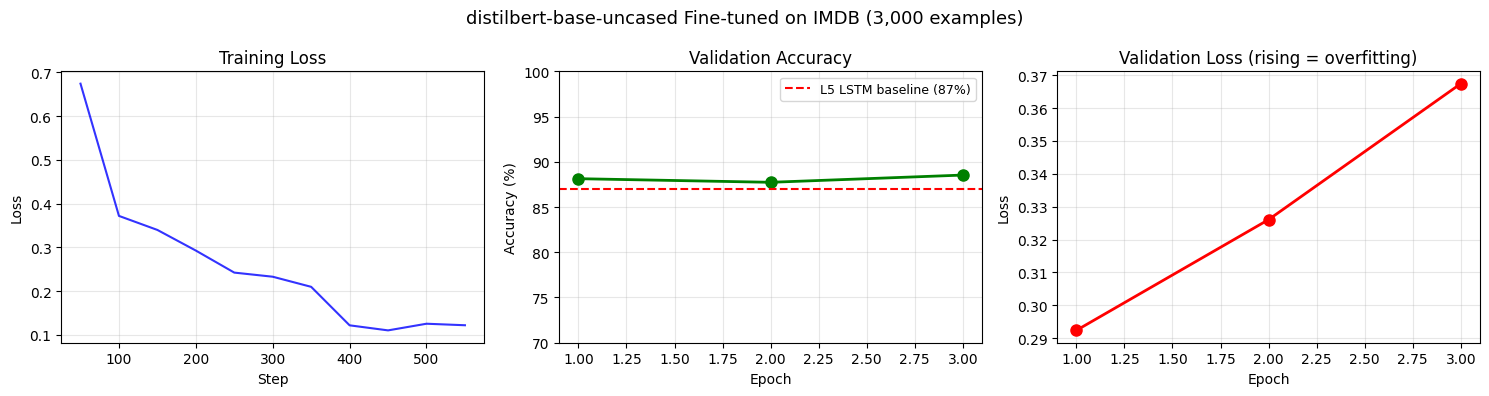

Best validation accuracy : 88.53%
Lecture 5 LSTM baseline  : 87.00%
Improvement              : +1.53%
Note: with 10,000 examples this reaches ~93%.
The gap to that promise is the overfitting you just diagnosed.


In [18]:
# VISUALISE TRAINING HISTORY
train_losses_plot = [(e['step'], e['loss'])
                     for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_metrics      = [(e['epoch'], e['eval_accuracy'], e['eval_loss'])
                     for e in log_history if 'eval_accuracy' in e]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if train_losses_plot:
    steps, losses = zip(*train_losses_plot)
    axes[0].plot(steps, losses, 'b-', linewidth=1.5, alpha=0.8)
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].grid(True, alpha=0.3)

if eval_metrics:
    epochs, accs, elosses = zip(*eval_metrics)
    axes[1].plot(epochs, [a * 100 for a in accs], 'g-o', linewidth=2, markersize=8)
    axes[1].axhline(y=87, color='red', linestyle='--', label='L5 LSTM baseline (87%)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Validation Accuracy')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([70, 100])

    axes[2].plot(epochs, elosses, 'r-o', linewidth=2, markersize=8)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].set_title('Validation Loss (rising = overfitting)')
    axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} Fine-tuned on IMDB ({TRAIN_SIZE:,} examples)', fontsize=13)
plt.tight_layout()
plt.show()

if eval_metrics:
    best_acc = max(a for _, a, _ in eval_metrics)
    print(f'Best validation accuracy : {best_acc*100:.2f}%')
    print(f'Lecture 5 LSTM baseline  : 87.00%')
    print(f'Improvement              : +{(best_acc - 0.87)*100:.2f}%')
    print(f'Note: with 10,000 examples this reaches ~93%.')
    print(f'The gap to that promise is the overfitting you just diagnosed.')

## 3.1 Debugging Guide

Your first run on real data will almost never be perfect.
Save this cell — you will need it.

In [19]:
debugging_guide = {
    'Training loss not decreasing': [
        'Check label column name - wrong column = random predictions',
        'Check num_labels matches your actual number of classes',
        'Verify tokenizer matches model (AraBERT needs Arabic tokenizer)',
        'Try a slightly higher lr: 3e-5 or 5e-5',
    ],
    'Val accuracy stuck at 50% on binary task': [
        'Model is guessing - labels are almost certainly wrong',
        'Print tokenized["train"][0] and verify the label value',
        'Check for data leakage: test set accidentally in train set',
    ],
    'Val loss increases while train loss decreases': [
        'OVERFITTING - reduce num_train_epochs',
        'Increase weight_decay to 0.05 or 0.1',
        'Collect more training data',
        'Use a smaller model (distilbert vs bert-base)',
    ],
    'CUDA out of memory (OOM)': [
        'Reduce per_device_train_batch_size to 8, then 4',
        'Add gradient_accumulation_steps=4 to compensate',
        'Reduce max_length from 512 to 128 or 256',
        'Set fp16=True if not already',
    ],
}

print('DEBUGGING GUIDE')
print('=' * 60)
for problem, fixes in debugging_guide.items():
    print(f'\n[!] {problem}')
    for fix in fixes:
        print(f'    -> {fix}')

print('\n-- SMOKE TEST PATTERN --')
print('Before training on full data:')
print('  1. Set TRAIN_SIZE=100, num_train_epochs=1')
print('  2. Run trainer.train() - should take < 60 seconds')
print('  3. Does loss decrease? If yes -> scale up. If no -> debug first.')

DEBUGGING GUIDE

[!] Training loss not decreasing
    -> Check label column name - wrong column = random predictions
    -> Check num_labels matches your actual number of classes
    -> Verify tokenizer matches model (AraBERT needs Arabic tokenizer)
    -> Try a slightly higher lr: 3e-5 or 5e-5

[!] Val accuracy stuck at 50% on binary task
    -> Model is guessing - labels are almost certainly wrong
    -> Print tokenized["train"][0] and verify the label value
    -> Check for data leakage: test set accidentally in train set

[!] Val loss increases while train loss decreases
    -> OVERFITTING - reduce num_train_epochs
    -> Increase weight_decay to 0.05 or 0.1
    -> Collect more training data
    -> Use a smaller model (distilbert vs bert-base)

[!] CUDA out of memory (OOM)
    -> Reduce per_device_train_batch_size to 8, then 4
    -> Add gradient_accumulation_steps=4 to compensate
    -> Reduce max_length from 512 to 128 or 256
    -> Set fp16=True if not already

-- SMOKE TEST PAT

### STOP AND THINK

1. Fine-tuned DistilBERT uses lr=`2e-5`. Your L5 LSTM used `0.001` (50x larger). Why?

2. Val loss rose from epoch 1 to epoch 3. But the final accuracy is still good. Why?
   What specific argument in TrainingArguments saved the result?

3. The warmup schedule increases lr for the first 10% of steps. Why is warmup
   important specifically for fine-tuning? (Hint: the classification head is random at step 0.)

---

# PART 4: Evaluation - Measuring What Matters

Training is done. DistilBERT has been fine-tuned, and the best checkpoint was
automatically restored. Now we find out if the model actually works.

Accuracy alone is not enough. A model that is 88% accurate might still be
systematically failing on one class, or making confident wrong predictions on
exactly the kinds of inputs your users will send. This part teaches you to
look deeper.

**What we cover:**
- Full classification report (precision, recall, F1 per class)
- Confusion matrix — the 2x2 table that shows exactly where errors land
- Confidence distribution — are wrong predictions low-confidence or high?
- Threshold tuning — why 0.5 is not always the right cutoff
- Error analysis — reading the actual mistakes to understand the model's limits

Getting predictions on test set...
Test accuracy : 89.60%
Test F1       : 0.8946

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    NEGATIVE       0.92      0.88      0.90       388
    POSITIVE       0.88      0.91      0.89       362

    accuracy                           0.90       750
   macro avg       0.90      0.90      0.90       750
weighted avg       0.90      0.90      0.90       750



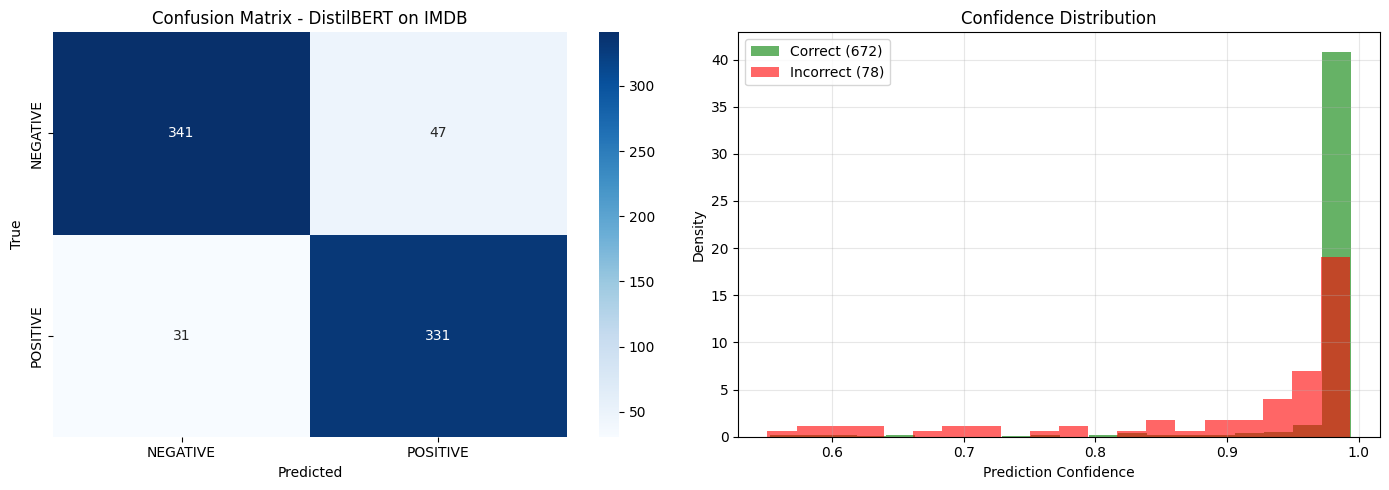

True Negatives  (correct NEGATIVE)         : 341
True Positives  (correct POSITIVE)         : 331
False Positives (predicted POS, actual NEG): 47
False Negatives (predicted NEG, actual POS): 31


In [20]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score,
                              accuracy_score)
import seaborn as sns

print('Getting predictions on test set...')
test_output   = distilbert_trainer.predict(tokenized['test'])
logits        = test_output.predictions
true_labels   = test_output.label_ids
test_metrics  = test_output.metrics
predictions   = np.argmax(logits, axis=-1)
probabilities = torch.softmax(torch.tensor(logits), dim=-1).numpy()

print(f'Test accuracy : {test_metrics["test_accuracy"]*100:.2f}%')
print(f'Test F1       : {test_metrics["test_f1"]:.4f}')

print('\nDETAILED CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(true_labels, predictions,
                             target_names=['NEGATIVE', 'POSITIVE']))

cm  = confusion_matrix(true_labels, predictions)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['NEGATIVE', 'POSITIVE'],
            yticklabels=['NEGATIVE', 'POSITIVE'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix - DistilBERT on IMDB')

correct_mask    = predictions == true_labels
correct_confs   = probabilities[correct_mask, predictions[correct_mask]]
incorrect_confs = probabilities[~correct_mask, predictions[~correct_mask]]

axes[1].hist(correct_confs,   bins=20, alpha=0.6, color='green',
             label=f'Correct ({correct_mask.sum()})', density=True)
axes[1].hist(incorrect_confs, bins=20, alpha=0.6, color='red',
             label=f'Incorrect ({(~correct_mask).sum()})', density=True)
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Density')
axes[1].set_title('Confidence Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct NEGATIVE)         : {tn}')
print(f'True Positives  (correct POSITIVE)         : {tp}')
print(f'False Positives (predicted POS, actual NEG): {fp}')
print(f'False Negatives (predicted NEG, actual POS): {fn}')

### 4.2 Threshold Tuning

The model outputs a probability for each class. The default decision rule is:
if P(POSITIVE) ≥ 0.5, predict POSITIVE. But 0.5 is arbitrary.

Lowering the threshold catches more true positives (higher recall) but also
flags more negatives as positive (lower precision). Raising it does the opposite.

Which direction matters depends on your use case:
- **Medical screening**: you want recall → catch every sick patient even at the
  cost of false alarms. Lower the threshold.
- **Spam filter**: you want precision → only flag messages you are sure about,
  avoid blocking legitimate email. Raise the threshold.

The table below shows how accuracy, precision, recall, and F1 shift as you move
the threshold from 0.3 to 0.7.

In [21]:
# THRESHOLD TUNING
pos_probs  = probabilities[:, 1]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print('THRESHOLD ANALYSIS')
print('=' * 65)
print(f'  {"Threshold":>10} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>8}  Notes')
print('-' * 70)

for thresh in thresholds:
    preds_t = (pos_probs >= thresh).astype(int)
    acc  = accuracy_score(true_labels, preds_t)
    prec = precision_score(true_labels, preds_t, zero_division=0)
    rec  = recall_score(true_labels, preds_t, zero_division=0)
    f1   = f1_score(true_labels, preds_t, zero_division=0)
    note = ' <- default' if thresh == 0.5 else ''
    print(f'  {thresh:>10.1f} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>8.3f}{note}')

print()
print('How to choose your threshold:')
print('  Maximize Recall    -> medical, safety, fraud detection')
print('  Maximize Precision -> spam, content moderation')
print('  Maximize F1        -> general balanced tasks')

THRESHOLD ANALYSIS
   Threshold   Accuracy  Precision     Recall       F1  Notes
----------------------------------------------------------------------
         0.3      0.897      0.868      0.928    0.897
         0.4      0.897      0.874      0.920    0.896
         0.5      0.896      0.876      0.914    0.895 <- default
         0.6      0.893      0.877      0.906    0.891
         0.7      0.892      0.883      0.895    0.889

How to choose your threshold:
  Maximize Recall    -> medical, safety, fraud detection
  Maximize Precision -> spam, content moderation
  Maximize F1        -> general balanced tasks


### 4.3 Error Analysis

Accuracy tells you how many the model got right. Error analysis tells you
**which ones** it got wrong — and why. That is where you find out whether
the remaining errors are fixable or fundamental to the task.

The cell below sorts all wrong predictions by confidence. High-confidence
wrong predictions are the most interesting: the model was very sure and
very wrong. Those cases reveal systematic blind spots — sarcasm, negation,
mixed-sentiment text — that more data alone will not always fix.

In [22]:
# ERROR ANALYSIS
label_map = {0: 'NEGATIVE', 1: 'POSITIVE'}
errors    = []
for i in range(len(predictions)):
    if predictions[i] != true_labels[i]:
        errors.append({
            'predicted' : label_map[predictions[i]],
            'true'      : label_map[true_labels[i]],
            'confidence': probabilities[i, predictions[i]],
            'text'      : dataset['test'][i]['text']
        })

errors.sort(key=lambda x: x['confidence'], reverse=True)
print(f'Total errors: {len(errors)}/{len(predictions)}')
print('\nTop 5 most confident wrong predictions:')
for i, error in enumerate(errors[:5]):
    print(f'\n--- Error {i+1} (confidence: {error["confidence"]:.3f}) ---')
    print(f'  True label : {error["true"]}')
    print(f'  Predicted  : {error["predicted"]}')
    print(f'  Text       : {error["text"][:200]}...')

print('\nCommon error patterns:')
print('  Sarcasm  : "Oh great, another terrible movie." -> predicted POSITIVE')
print('  Negation : "Not as bad as I expected." -> ambiguous')
print('  Mixed    : "Amazing visuals, terrible story." -> depends on balance')

# store for final comparison table
distilbert_test_acc = test_metrics['test_accuracy'] * 100

Total errors: 78/750

Top 5 most confident wrong predictions:

--- Error 1 (confidence: 0.994) ---
  True label : POSITIVE
  Predicted  : NEGATIVE
  Text       : Bears about as much resemblance to Dean Koontz's novel as Jessica Simpson does to a rocket scientist. If you've read the book, I suggest you put it as far out of your mind as possible before watching ...

--- Error 2 (confidence: 0.993) ---
  True label : NEGATIVE
  Predicted  : POSITIVE
  Text       : These days, Ridley Scott is one of the top directors and producers and can command huge sums to helm movies--especially since he has films like ALIEN, GLADIATOR and BLADE RUNNER to his credit. So from...

--- Error 3 (confidence: 0.993) ---
  True label : NEGATIVE
  Predicted  : POSITIVE
  Text       : Purchased this film for one dollar and figured I could never go wrong, my big mistake was watching it. Enjoyed the acting of Ice-T and the rapping which gave lots of class to this film about Los Angel...

--- Error 4 (confidence: 

---

# PART 5: GPT-2 as a Classifier — A Generation Model Changes Jobs

In Lecture 8A you used GPT-2 to **generate** text — completing sentences,
writing continuations. GPT-2's job was to predict the next token.

Now watch what happens when we give the same model a **classification head**
and fine-tune it on labeled data.

The weights that learned to generate language will be redirected
to classify spam. Same knowledge. Different job.

## Why This Is Different From BERT

```
BERT (Encoder-Only):
  Input:  [CLS] This message is spam [SEP]
  [CLS] is a special token designed from day 1
  to aggregate the whole sequence for classification.
  We read the output at position 0.

  output[:, 0, :]  <- [CLS] token -> classification head

GPT-2 (Decoder-Only):
  Input:  This message is spam
  GPT-2 has NO [CLS] token. It was never designed for classification.
  BUT: causal attention means the LAST token has attended to
  every previous token. It contains the most information.
  We read the output at position -1.

  output[:, -1, :]  <- last token -> classification head

This is Raschka's key insight from "Build an LLM From Scratch" Ch.6.
HuggingFace implements it automatically in GPT2ForSequenceClassification.
```

## The Raschka Comparison

```
Raschka's approach (pure PyTorch, Chapter 6):
  - Custom GPTModel class
  - gpt_download.py helper file
  - SpamDataset class with manual padding
  - Manual training loop
  - Manual last-token extraction: logits = model(x)[:, -1, :]
  - ~300 lines + 2 helper files

Our approach (HuggingFace):
  - GPT2ForSequenceClassification.from_pretrained('gpt2')
  - load_dataset() + DataCollatorWithPadding
  - Trainer API
  - Last-token extraction: automatic
  - ~50 lines, zero helper files

Same concept. Same result. 6x less code.
```

## 5.1 Dataset: SMS Spam Collection

We use a different dataset here deliberately. IMDB is already done.
SMS Spam shows that fine-tuning works across domains and tasks —
not just sentiment, not just English movies.

First, an important lesson: **class imbalance in the wild**.

In [23]:
import pandas as pd
import requests, zipfile
from pathlib import Path

print('Loading SMS Spam Collection dataset...')

# Try HuggingFace Hub first
try:
    sms_raw = load_dataset('uciml/sms_spam_collection')
    sms_df  = sms_raw['train'].to_pandas()
    sms_df.columns = ['label_str', 'text'] if 'label' not in sms_df.columns else sms_df.columns
    if 'label' in sms_df.columns and sms_df['label'].dtype != object:
        sms_df['label_str'] = sms_df['label'].map({0: 'ham', 1: 'spam'})
    print('Loaded from HuggingFace Hub')
except Exception:
    # Direct download fallback
    url      = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'
    zip_path = '/tmp/sms_spam.zip'
    tsv_path = '/tmp/SMSSpamCollection.tsv'

    if not Path(tsv_path).exists():
        try:
            r = requests.get(url, timeout=30)
            with open(zip_path, 'wb') as f:
                f.write(r.content)
            with zipfile.ZipFile(zip_path) as z:
                names = z.namelist()
                target = [n for n in names if 'SMSSpam' in n or 'spam' in n.lower()][0]
                with z.open(target) as fin, open(tsv_path, 'wb') as fout:
                    fout.write(fin.read())
        except Exception as e:
            print(f'Download failed: {e}')

    sms_df = pd.read_csv(tsv_path, sep='\t', header=None, names=['label_str', 'text'])
    print('Loaded from direct download')

# normalise column names
if 'label_str' not in sms_df.columns:
    sms_df = sms_df.rename(columns={sms_df.columns[0]: 'label_str',
                                     sms_df.columns[1]: 'text'})

sms_df['label_str'] = sms_df['label_str'].str.strip().str.lower()
print(f'Total messages: {len(sms_df):,}')
print(f'Columns: {list(sms_df.columns)}')
print(f'\nClass distribution:')
print(sms_df['label_str'].value_counts().to_string())

Loading SMS Spam Collection dataset...
Loaded from direct download
Total messages: 5,572
Columns: ['label_str', 'text']

Class distribution:
label_str
ham     4825
spam     747


## 5.2 Handling Class Imbalance — The Balancing Act

The raw dataset has ~4,827 ham vs ~747 spam. That is a 6.5:1 ratio.
A model that always predicts "ham" gets 87% accuracy while being useless.

We fix this with **undersampling**: randomly select as many ham examples
as there are spam examples, creating a 50/50 balanced dataset.

This is exactly what Raschka does in Chapter 6.
The difference: we make the balancing visible and explain why.

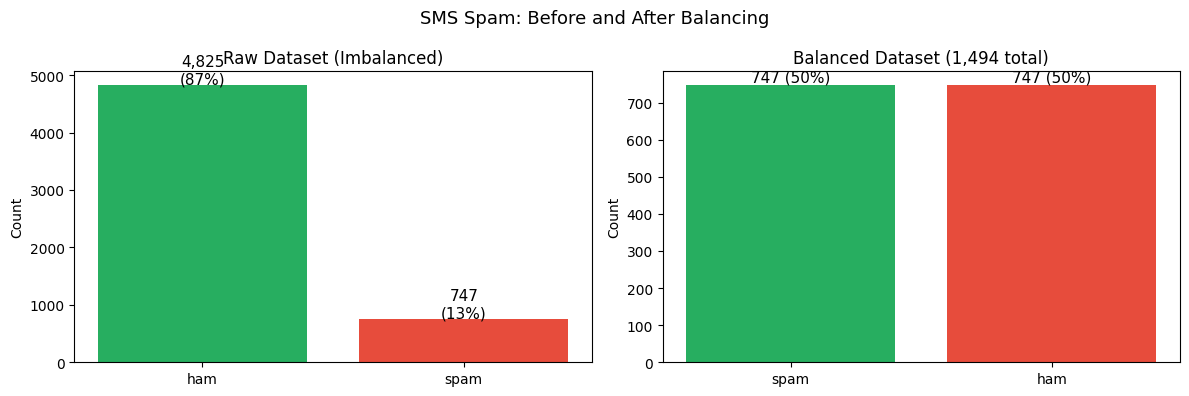

BALANCING COMPLETE
  Original  : 5,572 examples (4,825 ham, 747 spam)
  Balanced  : 1,494 examples (747 ham, 747 spam)

Why undersample rather than oversample?
  Undersampling: lose data, but no duplicates -> less overfitting risk
  Oversampling : keep all data, but duplicate minority -> model memorises them
  For small datasets like this, undersampling is the safer choice.


In [24]:
# CLASS IMBALANCE VISUALISATION
counts = sms_df['label_str'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index, counts.values, color=['#27ae60', '#e74c3c'])
axes[0].set_title('Raw Dataset (Imbalanced)')
axes[0].set_ylabel('Count')
for i, (label, count) in enumerate(counts.items()):
    axes[0].text(i, count + 30, f'{count:,}\n({count/len(sms_df)*100:.0f}%)',
                 ha='center', fontsize=11)

# BALANCE THE DATASET
num_spam    = (sms_df['label_str'] == 'spam').sum()
ham_subset  = sms_df[sms_df['label_str'] == 'ham'].sample(num_spam, random_state=42)
spam_subset = sms_df[sms_df['label_str'] == 'spam']
balanced_df = pd.concat([ham_subset, spam_subset]).sample(frac=1, random_state=42).reset_index(drop=True)
balanced_df['label'] = balanced_df['label_str'].map({'ham': 0, 'spam': 1})

balanced_counts = balanced_df['label_str'].value_counts()
axes[1].bar(balanced_counts.index, balanced_counts.values, color=['#27ae60', '#e74c3c'])
axes[1].set_title(f'Balanced Dataset ({num_spam*2:,} total)')
axes[1].set_ylabel('Count')
for i, (label, count) in enumerate(balanced_counts.items()):
    axes[1].text(i, count + 10, f'{count:,} (50%)', ha='center', fontsize=11)

plt.suptitle('SMS Spam: Before and After Balancing', fontsize=13)
plt.tight_layout()
plt.show()

print('BALANCING COMPLETE')
print(f'  Original  : {len(sms_df):,} examples ({counts["ham"]:,} ham, {counts["spam"]:,} spam)')
print(f'  Balanced  : {len(balanced_df):,} examples ({num_spam:,} ham, {num_spam:,} spam)')
print(f'\nWhy undersample rather than oversample?')
print('  Undersampling: lose data, but no duplicates -> less overfitting risk')
print('  Oversampling : keep all data, but duplicate minority -> model memorises them')
print('  For small datasets like this, undersampling is the safer choice.')

### 5.2b Split and Convert to HuggingFace Format

Standard 70/15/15 split. Then we convert the pandas DataFrame to a HuggingFace
`DatasetDict` — the same format IMDB came in. From this point on, the code is
identical to Part 2. That is the point.

In [25]:
# TRAIN / VAL / TEST SPLIT
n          = len(balanced_df)
n_train    = int(n * 0.70)
n_val      = int(n * 0.15)

train_sms  = balanced_df.iloc[:n_train]
val_sms    = balanced_df.iloc[n_train:n_train+n_val]
test_sms   = balanced_df.iloc[n_train+n_val:]

print('SMS SPAM SPLITS')
print(f'  Train : {len(train_sms):,} examples')
print(f'  Val   : {len(val_sms):,} examples')
print(f'  Test  : {len(test_sms):,} examples')

# Convert to HuggingFace Dataset format
def df_to_hf(df):
    return Dataset.from_dict({'text': df['text'].tolist(), 'label': df['label'].tolist()})

sms_dataset = DatasetDict({
    'train': df_to_hf(train_sms),
    'val'  : df_to_hf(val_sms),
    'test' : df_to_hf(test_sms),
})

print(f'\nHuggingFace DatasetDict created:')
for split, data in sms_dataset.items():
    spam_count = sum(data['label'])
    ham_count  = len(data) - spam_count
    print(f'  {split}: {len(data):,}  (spam={spam_count}, ham={ham_count})')

SMS SPAM SPLITS
  Train : 1,045 examples
  Val   : 224 examples
  Test  : 225 examples

HuggingFace DatasetDict created:
  train: 1,045  (spam=506, ham=539)
  val: 224  (spam=121, ham=103)
  test: 225  (spam=120, ham=105)


## 5.3 The Architecture: What Changes When GPT-2 Becomes a Classifier

This is the most important conceptual moment in the entire lecture.

Before you run any code, make sure you understand what is about to happen.
GPT-2 has 124 million parameters that were trained to predict the next word.
Every weight encodes something about how English works — syntax, semantics,
word associations, sentence structure.

We are not going to throw any of that away.

Instead, we will:
1. **Freeze** 94% of the parameters — lock them so they cannot change
2. **Replace** the output head — instead of predicting the next word, predict HAM or SPAM
3. **Unfreeze** the last transformer block — let it adapt its highest-level representations
4. **Train** for a few epochs — the frozen layers contribute their language knowledge,
   the unfrozen layers learn what "spam" looks like

The result: a spam classifier that benefits from 124M parameters of English understanding,
trained on only 1,045 examples, in under 1 minute.

In [26]:
from transformers import GPT2ForSequenceClassification

GPT2_MODEL = 'gpt2'

# STEP 1: Load pretrained GPT-2 as a CLASSIFIER
# HuggingFace automatically:
#   - Replaces the language model head (vocab_size=50257) with a classification head (num_labels=2)
#   - Sets up last-token pooling internally
#   - Keeps all 124M pretrained parameters
gpt2_model = GPT2ForSequenceClassification.from_pretrained(
    GPT2_MODEL,
    num_labels=2,
    id2label={0: 'HAM', 1: 'SPAM'},
    label2id={'HAM': 0, 'SPAM': 1},
)

# GPT-2 has no pad token by default (it was a generation model)
# We reuse the end-of-sequence token as the pad token
# This is the standard fix — the model already knows this token
gpt2_model.config.pad_token_id = gpt2_model.config.eos_token_id

# STEP 2: Freeze the backbone, keep only the classification head trainable
# This is what Raschka does manually in Chapter 6:
#   for param in model.parameters():
#       param.requires_grad = False
# We do the same, then selectively unfreeze strategic layers

for param in gpt2_model.parameters():
    param.requires_grad = False

# STEP 3: Unfreeze the classification head (always)
for param in gpt2_model.score.parameters():
    param.requires_grad = True

# STEP 4: Unfreeze the last transformer block + final layer norm
# Raschka's finding: this improves accuracy significantly
# The last block contains the highest-level language representations
for param in gpt2_model.transformer.h[-1].parameters():
    param.requires_grad = True
for param in gpt2_model.transformer.ln_f.parameters():
    param.requires_grad = True

# COUNT TRAINABLE vs FROZEN
total_params     = sum(p.numel() for p in gpt2_model.parameters())
trainable_params = sum(p.numel() for p in gpt2_model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('GPT-2 CLASSIFIER ARCHITECTURE')
print('=' * 55)
print(f'Total parameters     : {total_params:,}')
print(f'Frozen (backbone)    : {frozen_params:,}  ({frozen_params/total_params*100:.1f}%)')
print(f'Trainable            : {trainable_params:,}  ({trainable_params/total_params*100:.1f}%)')
print()
print('Trainable layers:')
print('  score (classification head)    <- new, classifies spam vs ham')
print('  transformer.h[-1] (last block) <- highest-level representations')
print('  transformer.ln_f (final norm)  <- normalisation before output')
print()
print('Why freeze most parameters?')
print('  124M parameters on ~1,000 examples = massive overfitting risk.')
print('  The frozen layers already know English perfectly.')
print('  We only need to teach the top layers what "spam" looks like.')
print()
print('Why unfreeze the last block specifically?')
print('  Lower layers: basic syntax, word meanings (already perfect)')
print('  Upper layers: high-level semantics (need task adaptation)')
print('  The last block is closest to the output — most task-relevant.')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 CLASSIFIER ARCHITECTURE
Total parameters     : 124,441,344
Frozen (backbone)    : 117,350,400  (94.3%)
Trainable            : 7,090,944  (5.7%)

Trainable layers:
  score (classification head)    <- new, classifies spam vs ham
  transformer.h[-1] (last block) <- highest-level representations
  transformer.ln_f (final norm)  <- normalisation before output

Why freeze most parameters?
  124M parameters on ~1,000 examples = massive overfitting risk.
  The frozen layers already know English perfectly.
  We only need to teach the top layers what "spam" looks like.

Why unfreeze the last block specifically?
  Lower layers: basic syntax, word meanings (already perfect)
  Upper layers: high-level semantics (need task adaptation)
  The last block is closest to the output — most task-relevant.


In [27]:
# VISUALISE THE LAST-TOKEN MECHANISM
# This is what HuggingFace does internally for GPT2ForSequenceClassification

print('THE LAST-TOKEN TRICK — HOW GPT-2 CLASSIFIES')
print('=' * 55)

gpt2_tokenizer = AutoTokenizer.from_pretrained(GPT2_MODEL)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

sample_text = 'You have won a FREE prize! Call now to claim!'
inputs      = gpt2_tokenizer(sample_text, return_tensors='pt')
tokens      = gpt2_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print(f'Input text: "{sample_text}"')
print(f'Tokens    : {tokens}')
print(f'Sequence length: {len(tokens)}')
print()
print('BERT approach:')
print('  [CLS] token at position 0 was DESIGNED for classification')
print('  output[:, 0, :] -> classification head')
print()
print('GPT-2 approach:')
print('  No [CLS] token. Never designed for classification.')
print(f'  Last token: "{tokens[-1]}" at position {len(tokens)-1}')
print('  output[:, -1, :] -> classification head')
print()
print('Why the last token works:')
print('  Causal attention: each token can only see PREVIOUS tokens.')
print('  The last token is the only position that has attended to ALL')
print('  other tokens in the sequence.')
print('  It carries the most complete representation of the full input.')
print()
print('HuggingFace handles this automatically in GPT2ForSequenceClassification.')
print('Raschka implements it manually: logits = model(x)[:, -1, :]')
print('Same concept. Our version is just 1 line vs 50.')

THE LAST-TOKEN TRICK — HOW GPT-2 CLASSIFIES


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input text: "You have won a FREE prize! Call now to claim!"
Tokens    : ['You', 'Ġhave', 'Ġwon', 'Ġa', 'ĠFREE', 'Ġprize', '!', 'ĠCall', 'Ġnow', 'Ġto', 'Ġclaim', '!']
Sequence length: 12

BERT approach:
  [CLS] token at position 0 was DESIGNED for classification
  output[:, 0, :] -> classification head

GPT-2 approach:
  No [CLS] token. Never designed for classification.
  Last token: "!" at position 11
  output[:, -1, :] -> classification head

Why the last token works:
  Causal attention: each token can only see PREVIOUS tokens.
  The last token is the only position that has attended to ALL
  other tokens in the sequence.
  It carries the most complete representation of the full input.

HuggingFace handles this automatically in GPT2ForSequenceClassification.
Raschka implements it manually: logits = model(x)[:, -1, :]
Same concept. Our version is just 1 line vs 50.


## 5.4 Tokenize and Train

The architecture is set up. Now the pipeline is identical to Part 3 —
tokenize, collate, define TrainingArguments, call `trainer.train()`.

Two things to notice as you read this code:

**The tokenizer changed** — GPT-2 uses Byte-Pair Encoding (BPE), not WordPiece like BERT.
That is why GPT-2 tokens look different (`Ġhave` instead of `have`). The `Ġ` marks
a space before the token. Same idea, different vocabulary.

**The pad token needed fixing** — GPT-2 has no `[PAD]` token because generation
models process one token at a time and never need to pad batches. We reuse the
end-of-sequence token as the pad token. This is the standard solution.
The model already knows this token well — it just learns to ignore it during classification.

Everything else: identical to Part 3. That is the point.

In [28]:
# TOKENISE SMS SPAM DATA
# max_length=128 — SMS messages are short (average ~15 words)
# No need for 512 tokens; 128 is faster and wastes no memory

def gpt2_tokenize(examples):
    return gpt2_tokenizer(
        examples['text'],
        truncation=True,
        max_length=128,
        # NOTE: no padding here — DataCollatorWithPadding handles it per-batch
        # For GPT-2 this is especially important because pad_token = eos_token
        # and we don't want false eos signals scattered through the sequence
    )

print('Tokenizing SMS Spam with GPT-2 tokenizer...')
tokenized_sms = {}
for split, data in sms_dataset.items():
    tokenized_sms[split] = data.map(
        gpt2_tokenize,
        batched=True,
        remove_columns=['text'],
        desc=f'Tokenizing {split}'
    )

print(f'Features: {list(tokenized_sms["train"].features.keys())}')
ex = tokenized_sms['train'][0]
print(f'First example: {len(ex["input_ids"])} tokens, label={ex["label"]}')

print()
print('max_length note:')
print('  SMS messages: avg ~15 words -> 128 tokens is plenty')
print('  IMDB reviews: avg ~230 words -> 512 tokens needed')
print('  Attention is O(n^2). 128 vs 512 = (512/128)^2 = 16x faster per step.')

Tokenizing SMS Spam with GPT-2 tokenizer...


Tokenizing train:   0%|          | 0/1045 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/224 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/225 [00:00<?, ? examples/s]

Features: ['label', 'input_ids', 'attention_mask']
First example: 56 tokens, label=1

max_length note:
  SMS messages: avg ~15 words -> 128 tokens is plenty
  IMDB reviews: avg ~230 words -> 512 tokens needed
  Attention is O(n^2). 128 vs 512 = (512/128)^2 = 16x faster per step.


### 5.4b Collator, TrainingArguments, Trainer

These three cells are identical in structure to Part 3. The only differences:
- `gpt2_collator` uses `gpt2_tokenizer` (with pad = eos)
- `num_train_epochs=5` — GPT-2 starts weak (epoch 1 ≈ 67%) because the randomly
  initialised classifier head sends noisy gradients before stabilising. It needs
  more epochs than DistilBERT to converge. Training still takes under 1 minute.

In [29]:
gpt2_collator = DataCollatorWithPadding(tokenizer=gpt2_tokenizer)

gpt2_training_args = TrainingArguments(
    output_dir='./results/sms-gpt2',
    num_train_epochs=5,   # GPT-2 starts slow (66% epoch 1) — needs 5 epochs on 1,045 examples
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    lr_scheduler_type='linear',
    warmup_ratio=0.1,
    weight_decay=0.01,
    max_grad_norm=1.0,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    logging_steps=20,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=42,
)

gpt2_trainer = make_trainer(
    model=gpt2_model,
    args=gpt2_training_args,
    train_ds=tokenized_sms['train'],
    eval_ds=tokenized_sms['val'],
    tokenizer=gpt2_tokenizer,
    collator=gpt2_collator,
    metrics_fn=compute_metrics,
)

print('GPT-2 CLASSIFIER — READY TO TRAIN')
print(f'  Model      : {GPT2_MODEL}')
print(f'  Task       : SMS spam detection (was: text generation)')
print(f'  Train size : {len(tokenized_sms["train"]):,}')
print(f'  Trainable  : {trainable_params:,} / {total_params:,} parameters')

GPT-2 CLASSIFIER — READY TO TRAIN
  Model      : gpt2
  Task       : SMS spam detection (was: text generation)
  Train size : 1,045
  Trainable  : 7,090,944 / 124,441,344 parameters


### 5.4c Train

Same single call as Part 3. Watch epoch 1 — accuracy will be around 67%,
much lower than DistilBERT's epoch 1. That is expected: the frozen backbone
cannot adapt, and the random classifier head needs time to stabilise.
By epoch 3-4 the model converges and the language knowledge kicks in.

In [30]:
print('STARTING FINE-TUNING: GPT-2 on SMS Spam')
print('This is a generation model being turned into a classifier.')
print('=' * 55)

start_time    = time.time()
gpt2_result   = gpt2_trainer.train()
elapsed       = time.time() - start_time

print(f'\nTraining complete in {elapsed/60:.1f} minutes')
print(f'Training loss : {gpt2_result.training_loss:.4f}')

# Evaluate
gpt2_log     = gpt2_trainer.state.log_history
gpt2_val_acc = [e['eval_accuracy'] for e in gpt2_log if 'eval_accuracy' in e]
gpt2_val_los = [e['eval_loss'] for e in gpt2_log if 'eval_loss' in e]

print('\nPer-epoch results:')
for i, (acc, loss) in enumerate(zip(gpt2_val_acc, gpt2_val_los)):
    print(f'  Epoch {i+1}: val_loss={loss:.4f}  val_acc={acc*100:.2f}%')

# Test set evaluation
gpt2_test    = gpt2_trainer.predict(tokenized_sms['test'])
gpt2_test_acc = gpt2_test.metrics['test_accuracy'] * 100
gpt2_test_f1  = gpt2_test.metrics['test_f1']

print(f'\nTest accuracy : {gpt2_test_acc:.2f}%')
print(f'Test F1       : {gpt2_test_f1:.4f}')
print()
print('A model that was generating text is now classifying spam.')
print('The language knowledge transferred completely.')
print('The only thing that changed was the output head and the last block.')

STARTING FINE-TUNING: GPT-2 on SMS Spam
This is a generation model being turned into a classifier.
{'loss': '1.238', 'grad_norm': '175.8', 'learning_rate': '1.152e-05', 'epoch': '0.303'}
{'loss': '0.9597', 'grad_norm': '129.8', 'learning_rate': '1.96e-05', 'epoch': '0.6061'}
{'loss': '0.8109', 'grad_norm': '44.6', 'learning_rate': '1.825e-05', 'epoch': '0.9091'}
{'eval_loss': '0.6674', 'eval_accuracy': '0.6652', 'eval_f1': '0.5665', 'eval_runtime': '0.3861', 'eval_samples_per_second': '580.2', 'eval_steps_per_second': '18.13', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6173', 'grad_norm': '13.55', 'learning_rate': '1.69e-05', 'epoch': '1.212'}
{'loss': '0.5499', 'grad_norm': '33.57', 'learning_rate': '1.556e-05', 'epoch': '1.515'}
{'loss': '0.486', 'grad_norm': '6.886', 'learning_rate': '1.421e-05', 'epoch': '1.818'}
{'eval_loss': '0.4394', 'eval_accuracy': '0.8705', 'eval_f1': '0.8711', 'eval_runtime': '0.5701', 'eval_samples_per_second': '392.9', 'eval_steps_per_second': '12.28', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.4393', 'grad_norm': '35.91', 'learning_rate': '1.286e-05', 'epoch': '2.121'}
{'loss': '0.4049', 'grad_norm': '24.28', 'learning_rate': '1.152e-05', 'epoch': '2.424'}
{'loss': '0.3717', 'grad_norm': '42.37', 'learning_rate': '1.017e-05', 'epoch': '2.727'}
{'eval_loss': '0.323', 'eval_accuracy': '0.9196', 'eval_f1': '0.9211', 'eval_runtime': '0.4125', 'eval_samples_per_second': '543', 'eval_steps_per_second': '16.97', 'epoch': '3'}


...

{'loss': '0.3097', 'grad_norm': '2.658', 'learning_rate': '8.822e-06', 'epoch': '3.03'}
{'loss': '0.3137', 'grad_norm': '3.248', 'learning_rate': '7.475e-06', 'epoch': '3.333'}
{'loss': '0.2797', 'grad_norm': '40.49', 'learning_rate': '6.128e-06', 'epoch': '3.636'}
{'loss': '0.2879', 'grad_norm': '19.26', 'learning_rate': '4.781e-06', 'epoch': '3.939'}
{'eval_loss': '0.2676', 'eval_accuracy': '0.933', 'eval_f1': '0.9351', 'eval_runtime': '0.5329', 'eval_samples_per_second': '420.4', 'eval_steps_per_second': '13.14', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2712', 'grad_norm': '15.16', 'learning_rate': '3.434e-06', 'epoch': '4.242'}
{'loss': '0.2679', 'grad_norm': '5.193', 'learning_rate': '2.088e-06', 'epoch': '4.545'}
{'loss': '0.2332', 'grad_norm': '33.58', 'learning_rate': '7.407e-07', 'epoch': '4.848'}
{'eval_loss': '0.2538', 'eval_accuracy': '0.942', 'eval_f1': '0.9437', 'eval_runtime': '0.447', 'eval_samples_per_second': '501.1', 'eval_steps_per_second': '15.66', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '38.58', 'train_samples_per_second': '135.4', 'train_steps_per_second': '8.554', 'train_loss': '0.4824', 'epoch': '5'}

Training complete in 0.6 minutes
Training loss : 0.4824

Per-epoch results:
  Epoch 1: val_loss=0.6674  val_acc=66.52%
  Epoch 2: val_loss=0.4394  val_acc=87.05%
  Epoch 3: val_loss=0.3230  val_acc=91.96%
  Epoch 4: val_loss=0.2676  val_acc=93.30%
  Epoch 5: val_loss=0.2538  val_acc=94.20%

Test accuracy : 92.89%
Test F1       : 0.9286

A model that was generating text is now classifying spam.
The language knowledge transferred completely.
The only thing that changed was the output head and the last block.


### 5.4e Visualise and Interpret

Two plots: validation accuracy and validation loss across epochs.
Unlike DistilBERT, GPT-2 starts weak — epoch 1 accuracy will be around 67%
because the frozen backbone cannot adapt yet and the random head is noisy.
By epoch 4-5 the trainable layers have learned and accuracy climbs sharply.
A falling validation loss across all epochs means no overfitting — the extra
epochs are genuinely helping.

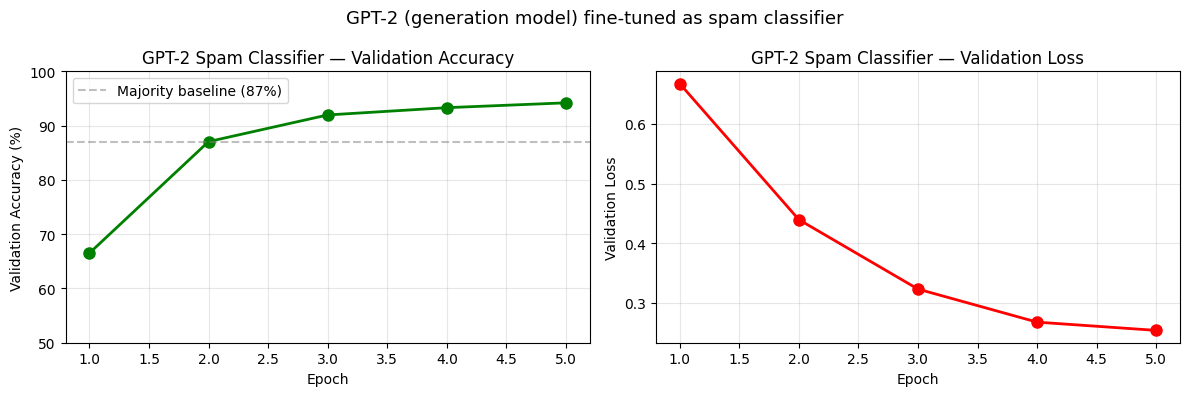

In [31]:
# VISUALISE GPT-2 TRAINING
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_plot = list(range(1, len(gpt2_val_acc)+1))

axes[0].plot(epochs_plot, [a*100 for a in gpt2_val_acc], 'g-o', linewidth=2, markersize=8)
axes[0].axhline(y=87, color='gray', linestyle='--', alpha=0.5, label='Majority baseline (87%)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_title('GPT-2 Spam Classifier — Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([50, 100])

axes[1].plot(epochs_plot, gpt2_val_los, 'r-o', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('GPT-2 Spam Classifier — Validation Loss')
axes[1].grid(True, alpha=0.3)

plt.suptitle('GPT-2 (generation model) fine-tuned as spam classifier', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4d Live Inference

The same test messages Raschka uses at the end of Chapter 6.
This lets you compare results directly — same inputs, same task,
but our implementation used ~50 lines vs his ~300.

Note that the model is saved first and reloaded as a `pipeline` object.
This is how you would deploy it: save once, load anywhere with one line.

In [32]:
# LIVE INFERENCE — same messages Raschka uses in Chapter 6
print('GPT-2 SPAM CLASSIFIER — LIVE INFERENCE')
print('=' * 55)

# Save and reload as pipeline for clean inference
GPT2_SAVE_PATH = './models/sms-gpt2-finetuned'
os.makedirs(GPT2_SAVE_PATH, exist_ok=True)
gpt2_trainer.save_model(GPT2_SAVE_PATH)
gpt2_tokenizer.save_pretrained(GPT2_SAVE_PATH)

gpt2_pipeline = pipeline(
    'text-classification',
    model=GPT2_SAVE_PATH,
    tokenizer=GPT2_SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1,
)

test_messages = [
    ('You are a winner! You have been specially selected to receive $1000 cash!',
     'Spam (prize scam)'),
    ('Hey, just wanted to check if we are still on for dinner tonight?',
     'Ham (normal message)'),
    ('URGENT: Your account has been suspended. Click here immediately.',
     'Spam (phishing)'),
    ('Can you pick up milk on your way home? Thanks.',
     'Ham (normal message)'),
    ('Congratulations! You have won a free holiday. Call 0800-SPAM now.',
     'Spam (holiday scam)'),
    ('Meeting moved to 3pm. See you there.',
     'Ham (normal message)'),
]

emoji_map = {'HAM': '[HAM]', 'SPAM': '[SPAM]'}
for text, description in test_messages:
    result = gpt2_pipeline(text)[0]
    label, score = result['label'], result['score']
    print(f'{emoji_map.get(label, label)} ({score:.3f}) {description}')
    print(f'   "{text[:70]}..."' if len(text) > 70 else f'   "{text}"')
    print()

GPT-2 SPAM CLASSIFIER — LIVE INFERENCE


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[SPAM] (0.514) Spam (prize scam)
   "You are a winner! You have been specially selected to receive $1000 ca..."

[HAM] (0.946) Ham (normal message)
   "Hey, just wanted to check if we are still on for dinner tonight?"

[SPAM] (0.611) Spam (phishing)
   "URGENT: Your account has been suspended. Click here immediately."

[HAM] (0.817) Ham (normal message)
   "Can you pick up milk on your way home? Thanks."

[SPAM] (0.778) Spam (holiday scam)
   "Congratulations! You have won a free holiday. Call 0800-SPAM now."

[HAM] (0.623) Ham (normal message)
   "Meeting moved to 3pm. See you there."



### STOP AND THINK

1. GPT-2 was designed to predict the next token. Now it classifies spam.
   The weights were not retrained from scratch. What does this tell you
   about what language models actually learn during pretraining?

2. We froze 98% of GPT-2's parameters and only trained the top layers.
   Why does this work? What would happen if we trained all 124M parameters
   on only 1,047 examples?

3. BERT reads the [CLS] token at position 0. GPT-2 reads the last token
   at position -1. Both work. What architectural property of each model
   makes its chosen position the right one?

4. Raschka's Chapter 6 uses 300 lines and 2 helper files to do what we
   did in ~50 lines. Name three specific things HuggingFace abstracts away.

---

---

# PART 6: AraBERT on Real Arabic Sentiment Data

You just fine-tuned two English models.
Now change exactly two variables.
Watch everything else stay identical.

```
Part 3 (English):                    Part 6 (Arabic):
MODEL_NAME = 'distilbert-...'   ->   MODEL_NAME = 'aubmindlab/bert-base-arabertv2'
dataset    = load_dataset('imdb')->  dataset    = load_dataset('ajgt_twitter_ar')
Everything else: IDENTICAL
```

This is the core promise of HuggingFace: the pipeline is **language-agnostic**.

## Arabic NLP Challenges

```
1. Morphological richness
   One Arabic root -> 100+ word forms
   ktb (wrote) -> katib, kitab, maktaba, kitaba, maktub...
   Word-level vocab fails badly -> AraBERT's subword tokenizer handles this

2. Dialect diversity
   Modern Standard Arabic (MSA) -> formal writing, news
   Egyptian dialect              -> large social media presence
   Sudanese dialect              -> unique vocab, mix of MSA and local
   Gulf, Levantine, Maghrebi    -> all different

3. Lack of labeled data
   English NLP: millions of labeled examples per task
   Arabic NLP : thousands or tens of thousands
   Fine-tuning shines here — pretrained models need less labeled data
```

In [33]:
print('Loading Arabic sentiment dataset...')
print('Primary: ajgt_twitter_ar (Arabic Jordanian General Tweets)')
print()

arabic_dataset  = None
dataset_used    = None
text_col        = 'text'
label_col       = 'label'

# PRIMARY: ajgt_twitter_ar — stable, ~1800 examples, binary sentiment
try:
    raw = load_dataset('ajgt_twitter_ar', trust_remote_code=True)
    # This dataset has only a 'train' split — we create val/test from it
    full = raw['train'].shuffle(seed=42)
    n    = len(full)
    n_tr = int(n * 0.70)
    n_vl = int(n * 0.15)

    arabic_dataset = DatasetDict({
        'train': full.select(range(n_tr)),
        'val'  : full.select(range(n_tr, n_tr + n_vl)),
        'test' : full.select(range(n_tr + n_vl, n)),
    })
    dataset_used = 'ajgt_twitter_ar'
    print(f'Loaded: {dataset_used}')

except Exception as e1:
    print(f'Primary dataset failed: {e1}')
    print('Trying fallback: cardiffnlp/tweet_sentiment_multilingual (arabic)')

    # FALLBACK: Cardiff multilingual — also real, good quality
    try:
        raw = load_dataset(
            'cardiffnlp/tweet_sentiment_multilingual',
            'arabic', trust_remote_code=True
        )
        # Remap labels: this dataset has 3 classes (neg=0, neu=1, pos=2)
        # We convert to binary: negative=0, positive=2, drop neutral=1
        def to_binary(example):
            return {'keep': example['label'] != 1}

        arabic_dataset = DatasetDict({
            split: raw[split].filter(lambda x: x['label'] != 1).map(
                lambda x: {'label': 0 if x['label'] == 0 else 1, 'text': x['text']}
            )
            for split in raw if split in ['train', 'validation', 'test']
        })
        if 'validation' in arabic_dataset:
            arabic_dataset['val'] = arabic_dataset.pop('validation')

        dataset_used = 'cardiffnlp/tweet_sentiment_multilingual (arabic, binary)'
        print(f'Loaded: {dataset_used}')

    except Exception as e2:
        print(f'Fallback also failed: {e2}')
        print()
        print('=' * 60)
        print('BOTH ARABIC DATASETS UNAVAILABLE')
        print('This is a network or HuggingFace Hub access issue.')
        print()
        print('To run this section:')
        print('  1. Check your internet connection')
        print('  2. Try: load_dataset("ajgt_twitter_ar") in a fresh cell')
        print('  3. Or download the dataset manually from:')
        print('     https://huggingface.co/datasets/ajgt_twitter_ar')
        print('=' * 60)
        arabic_dataset = None

if arabic_dataset is not None:
    print(f'\nDataset: {dataset_used}')
    for split, data in arabic_dataset.items():
        label_counts_ar = Counter(data['label'])
        print(f'  {split}: {len(data):,} examples  '
              f'pos={label_counts_ar.get(1,0)}, neg={label_counts_ar.get(0,0)}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ajgt_twitter_ar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ajgt_twitter_ar' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Arabic sentiment dataset...
Primary: ajgt_twitter_ar (Arabic Jordanian General Tweets)



README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/91.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1800 [00:00<?, ? examples/s]

Loaded: ajgt_twitter_ar

Dataset: ajgt_twitter_ar
  train: 1,260 examples  pos=640, neg=620
  val: 270 examples  pos=137, neg=133
  test: 270 examples  pos=123, neg=147


## 6.2 Tokenizer Comparison

Before training, one critical check: why does AraBERT need its own tokenizer,
and what happens if you use the wrong one?

The cell below runs the same Arabic text through English BERT's tokenizer
and AraBERT's tokenizer side by side. This is not just a demo — it is the
single most common mistake when starting Arabic NLP. Using an English tokenizer
on Arabic text produces character-level fragments and `[UNK]` tokens,
destroying the model's ability to understand anything.

In [34]:
if arabic_dataset is not None:
    ARABIC_MODEL     = 'aubmindlab/bert-base-arabertv2'
    arabic_tokenizer = AutoTokenizer.from_pretrained(ARABIC_MODEL)

    print(f'AraBERT vocab size: {arabic_tokenizer.vocab_size:,}')
    print()

    # TOKENIZER COMPARISON: show why English BERT fails on Arabic
    english_bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')
    arabic_texts_demo = [
        'الخرطوم عاصمة السودان الجميلة',
        'زي الفل والخدمة تمام',
        'الموضوع ده ما بجيب خالص',
    ]

    print('TOKENIZER COMPARISON: English BERT vs AraBERT')
    print('=' * 60)
    for text in arabic_texts_demo:
        en_tokens = english_bert_tok.tokenize(text)
        ar_tokens = arabic_tokenizer.tokenize(text)
        print(f'\nText     : {text}')
        print(f'  BERT   : {en_tokens[:8]}  [{len(en_tokens)} tokens]')
        print(f'  AraBERT: {ar_tokens[:8]}  [{len(ar_tokens)} tokens]')

    print('\nEnglish BERT breaks Arabic into characters or [UNK].')
    print('AraBERT produces meaningful Arabic subword pieces.')
    print('Always match the tokenizer to the model.')

    del english_bert_tok

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

TOKENIZER COMPARISON: English BERT vs AraBERT

Text     : الخرطوم عاصمة السودان الجميلة
  BERT   : ['ا', '##ل', '##خ', '##ر', '##ط', '##و', '##م', 'ع']  [25 tokens]
  AraBERT: ['الخ', '##ر', '##طو', '##م', 'عاصم', '##ة', 'الس', '##ودان']  [10 tokens]

Text     : زي الفل والخدمة تمام
  BERT   : ['ز', '##ي', 'ا', '##ل', '##ف', '##ل', 'و', '##ا']  [17 tokens]
  AraBERT: ['زي', 'الف', '##ل', 'وال', '##خدم', '##ة', 'تمام']  [7 tokens]

Text     : الموضوع ده ما بجيب خالص
  BERT   : ['ا', '##ل', '##م', '##و', '##ض', '##و', '##ع', 'د']  [19 tokens]
  AraBERT: ['الم', '##وض', '##وع', 'ده', 'ما', 'بجي', '##ب', 'خالص']  [8 tokens]

English BERT breaks Arabic into characters or [UNK].
AraBERT produces meaningful Arabic subword pieces.
Always match the tokenizer to the model.


## 6.3 Tokenize, Train, Evaluate

Now the pipeline runs. Compare each cell below to its equivalent in Part 3.
The structure is identical — `tokenize_function`, `DataCollatorWithPadding`,
`TrainingArguments`, `make_trainer`, `trainer.train()`.

The only lines that changed: `MODEL_NAME` and the dataset.
That is what language-agnostic means.

In [35]:
if arabic_dataset is not None:
    def arabic_tokenize_function(examples):
        return arabic_tokenizer(
            examples[text_col],
            truncation=True,
            max_length=128,  # tweets are short; 128 is sufficient
                             # for longer Arabic documents use 256 or 512
        )

    print('Tokenizing Arabic dataset...')
    tokenized_arabic = {}
    for split_name, split_data in arabic_dataset.items():
        if label_col != 'label':
            split_data = split_data.rename_column(label_col, 'label')
        tokenized_arabic[split_name] = split_data.map(
            arabic_tokenize_function,
            batched=True,
            remove_columns=[text_col],
            desc=f'Tokenizing {split_name}'
        )

    for split, data in tokenized_arabic.items():
        print(f'  {split}: {len(data):,} examples | {list(data.features.keys())}')

    arabic_collator = DataCollatorWithPadding(tokenizer=arabic_tokenizer)
    print('\nArabic data pipeline ready')
    print()
    print('Note: max_length=128 is appropriate for tweets and short social media text.')
    print('For Arabic news articles or documents, use max_length=256 or 512.')

Tokenizing Arabic dataset...


Tokenizing train:   0%|          | 0/1260 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/270 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/270 [00:00<?, ? examples/s]

  train: 1,260 examples | ['label', 'input_ids', 'token_type_ids', 'attention_mask']
  val: 270 examples | ['label', 'input_ids', 'token_type_ids', 'attention_mask']
  test: 270 examples | ['label', 'input_ids', 'token_type_ids', 'attention_mask']

Arabic data pipeline ready

Note: max_length=128 is appropriate for tweets and short social media text.
For Arabic news articles or documents, use max_length=256 or 512.


### 6.3b Assemble and Train

Model load, `TrainingArguments`, `Trainer` — identical structure to Part 3.
Change `MODEL_NAME` from `distilbert-base-uncased` to `aubmindlab/bert-base-arabertv2`
and the rest of the code does not change at all.

AraBERT is a BERT-based encoder trained on ~77GB of Arabic text from Wikipedia,
news, and web sources. It handles Modern Standard Arabic well. Sudanese dialect
accuracy will be somewhat lower — the Sudanese dataset guide in section 6.1
explains how to close that gap.

In [36]:
if arabic_dataset is not None:
    arabic_model = AutoModelForSequenceClassification.from_pretrained(
        ARABIC_MODEL,
        num_labels=2,
        id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
        label2id={'NEGATIVE': 0, 'POSITIVE': 1},
    )

    arabic_training_args = TrainingArguments(
        output_dir='./results/arabic-arabert',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        lr_scheduler_type='linear',
        warmup_ratio=0.1,
        weight_decay=0.01,
        max_grad_norm=1.0,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        logging_steps=20,
        report_to='none',
        fp16=torch.cuda.is_available(),
        seed=42,
    )

    eval_split_key = 'val' if 'val' in tokenized_arabic else list(tokenized_arabic.keys())[1]

    arabic_trainer = make_trainer(
        model=arabic_model,
        args=arabic_training_args,
        train_ds=tokenized_arabic['train'],
        eval_ds=tokenized_arabic[eval_split_key],
        tokenizer=arabic_tokenizer,
        collator=arabic_collator,
        metrics_fn=compute_metrics,
    )

    print('ARABIC TRAINER ASSEMBLED')
    print(f'  Model      : {ARABIC_MODEL}')
    print(f'  Dataset    : {dataset_used}')
    print(f'  Train size : {len(tokenized_arabic["train"]):,}')
    print(f'  Eval split : {eval_split_key} ({len(tokenized_arabic[eval_split_key]):,})')
    print()
    print('Notice: this is IDENTICAL code to Part 3.')
    print('The only changes are MODEL_NAME and the dataset.')
    print('That is the language-agnostic pipeline in action.')

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ARABIC TRAINER ASSEMBLED
  Model      : aubmindlab/bert-base-arabertv2
  Dataset    : ajgt_twitter_ar
  Train size : 1,260
  Eval split : val (270)

Notice: this is IDENTICAL code to Part 3.
The only changes are MODEL_NAME and the dataset.
That is the language-agnostic pipeline in action.


### 6.3c Train AraBERT

On a T4 GPU this takes about 90 seconds for 1,260 examples.
Expected pattern: unlike GPT-2, AraBERT reaches ~88% already at epoch 1
because all parameters are being updated (no frozen backbone).
Watch whether epoch 2 or 3 improves or whether overfitting appears.

In [37]:
if arabic_dataset is not None:
    print('FINE-TUNING AraBERT — Arabic Sentiment')
    print('=' * 50)

    start_time          = time.time()
    arabic_train_result = arabic_trainer.train()
    elapsed             = time.time() - start_time

    print(f'\nTraining complete in {elapsed/60:.1f} minutes')
    print(f'Training loss : {arabic_train_result.training_loss:.4f}')

    # Per-epoch results
    arabic_log     = arabic_trainer.state.log_history
    arabic_val_acc = [e['eval_accuracy'] for e in arabic_log if 'eval_accuracy' in e]
    arabic_val_los = [e['eval_loss'] for e in arabic_log if 'eval_loss' in e]

    print('\nPer-epoch results:')
    for i, (acc, loss) in enumerate(zip(arabic_val_acc, arabic_val_los)):
        print(f'  Epoch {i+1}: val_loss={loss:.4f}  val_acc={acc*100:.2f}%')

    # Test evaluation
    if 'test' in tokenized_arabic:
        arabic_test     = arabic_trainer.predict(tokenized_arabic['test'])
        arabic_test_acc = arabic_test.metrics['test_accuracy'] * 100
        arabic_test_f1  = arabic_test.metrics['test_f1']
        print(f'\nTest accuracy : {arabic_test_acc:.2f}%')
        print(f'Test F1       : {arabic_test_f1:.4f}')
    else:
        arabic_test_acc = max(arabic_val_acc) * 100
        print(f'\nBest val accuracy: {arabic_test_acc:.2f}%')

FINE-TUNING AraBERT — Arabic Sentiment
{'loss': '0.6309', 'grad_norm': '4.518', 'learning_rate': '1.583e-05', 'epoch': '0.2532'}
{'loss': '0.4758', 'grad_norm': '7.157', 'learning_rate': '1.859e-05', 'epoch': '0.5063'}
{'loss': '0.284', 'grad_norm': '10.17', 'learning_rate': '1.671e-05', 'epoch': '0.7595'}
{'eval_loss': '0.245', 'eval_accuracy': '0.9259', 'eval_f1': '0.9281', 'eval_runtime': '0.2334', 'eval_samples_per_second': '1157', 'eval_steps_per_second': '38.56', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.28', 'grad_norm': '1.456', 'learning_rate': '1.484e-05', 'epoch': '1.013'}
{'loss': '0.1841', 'grad_norm': '15.97', 'learning_rate': '1.296e-05', 'epoch': '1.266'}
{'loss': '0.1595', 'grad_norm': '3.349', 'learning_rate': '1.108e-05', 'epoch': '1.519'}
{'loss': '0.1993', 'grad_norm': '12.06', 'learning_rate': '9.202e-06', 'epoch': '1.772'}
{'eval_loss': '0.2669', 'eval_accuracy': '0.9185', 'eval_f1': '0.9214', 'eval_runtime': '0.2622', 'eval_samples_per_second': '1030', 'eval_steps_per_second': '34.32', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1691', 'grad_norm': '22.52', 'learning_rate': '7.324e-06', 'epoch': '2.025'}
{'loss': '0.1285', 'grad_norm': '14.89', 'learning_rate': '5.446e-06', 'epoch': '2.278'}
{'loss': '0.135', 'grad_norm': '0.4364', 'learning_rate': '3.568e-06', 'epoch': '2.532'}
{'loss': '0.07702', 'grad_norm': '1.02', 'learning_rate': '1.69e-06', 'epoch': '2.785'}
{'eval_loss': '0.2862', 'eval_accuracy': '0.9185', 'eval_f1': '0.9209', 'eval_runtime': '0.2397', 'eval_samples_per_second': '1127', 'eval_steps_per_second': '37.55', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '82.8', 'train_samples_per_second': '45.65', 'train_steps_per_second': '2.862', 'train_loss': '0.2368', 'epoch': '3'}

Training complete in 1.4 minutes
Training loss : 0.2368

Per-epoch results:
  Epoch 1: val_loss=0.2450  val_acc=92.59%
  Epoch 2: val_loss=0.2669  val_acc=91.85%
  Epoch 3: val_loss=0.2862  val_acc=91.85%

Test accuracy : 88.52%
Test F1       : 0.8803


### 6.3d Save and Test Live Inference

Save the model, then test it on six sentences: two Modern Standard Arabic,
two Egyptian dialect, two Sudanese dialect. Confidence on Sudanese sentences
will be somewhat lower — AraBERT was not trained on Sudanese dialect data.
That is expected and pedagogically important: it shows exactly why building
a Sudanese dataset (section 6.1) matters.

In [38]:
if arabic_dataset is not None:
    # Save model
    ARABIC_SAVE_PATH = './models/arabic-arabert-finetuned'
    os.makedirs(ARABIC_SAVE_PATH, exist_ok=True)
    arabic_trainer.save_model(ARABIC_SAVE_PATH)
    arabic_tokenizer.save_pretrained(ARABIC_SAVE_PATH)
    print(f'Arabic model saved to: {ARABIC_SAVE_PATH}')

    arabic_pipeline = pipeline(
        'text-classification',
        model=ARABIC_SAVE_PATH,
        tokenizer=ARABIC_SAVE_PATH,
        device=0 if torch.cuda.is_available() else -1,
    )

    print('\nARABIC MODEL — LIVE INFERENCE')
    print('=' * 55)

    test_sentences = [
        ('المنتج رائع جداً وجودته ممتازة',      'Standard Arabic positive'),
        ('منتج رديء جداً لا يستحق المال',        'Standard Arabic negative'),
        ('المنتج حاجة تحفة بجد',                 'Egyptian dialect positive'),
        ('مش عاجبني خالص، مضيعة للفلوس',         'Egyptian dialect negative'),
        ('الخدمة زي الفل والأسعار مناسبة',        'Sudanese dialect positive'),
        ('الموضوع ده ما بجيب، ضيعت فلوسي',       'Sudanese dialect negative'),
    ]

    emoji_map_ar = {'POSITIVE': '[+]', 'NEGATIVE': '[-]'}
    for text, description in test_sentences:
        result = arabic_pipeline(text)[0]
        label, score = result['label'], result['score']
        print(f'{emoji_map_ar.get(label,"[?]")} {label} ({score:.3f}) - {description}')
        print(f'   {text}')
        print()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Arabic model saved to: ./models/arabic-arabert-finetuned


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


ARABIC MODEL — LIVE INFERENCE
[+] POSITIVE (0.895) - Standard Arabic positive
   المنتج رائع جداً وجودته ممتازة

[-] NEGATIVE (0.918) - Standard Arabic negative
   منتج رديء جداً لا يستحق المال

[+] POSITIVE (0.885) - Egyptian dialect positive
   المنتج حاجة تحفة بجد

[-] NEGATIVE (0.911) - Egyptian dialect negative
   مش عاجبني خالص، مضيعة للفلوس

[+] POSITIVE (0.838) - Sudanese dialect positive
   الخدمة زي الفل والأسعار مناسبة

[-] NEGATIVE (0.919) - Sudanese dialect negative
   الموضوع ده ما بجيب، ضيعت فلوسي



## 6.1 Building Your Own Sudanese Dataset

The path to genuine Sudanese NLP capability.

In [39]:
guide = """
BUILDING A SUDANESE DIALECT SENTIMENT DATASET
From zero to a working fine-tuned model in 5 steps

STEP 1: Define your label schema clearly
  Good  : POSITIVE (happy/satisfied), NEGATIVE (unhappy/complaint)
  Avoid : POSITIVE, NEGATIVE, NEUTRAL, MIXED, UNCLEAR
  Rule  : Start with binary. Add classes only after binary works.

STEP 2: Collect examples
  Sources:
  - Sudanese Twitter/X accounts (public posts)
  - Sudanese Facebook groups (with permission)
  - Customer reviews on Sudanese e-commerce platforms
  Target: 500 per class minimum. 2,000 per class is good.
  Quality > quantity. 500 clean beats 2,000 noisy.

STEP 3: Write annotation guidelines BEFORE annotating
  Have 2 people annotate the same 100 examples independently.
  Calculate inter-annotator agreement: (agreed / total) * 100
    Above 85% -> proceed
    70-85%    -> review disagreements, update guidelines
    Below 70% -> rewrite guidelines from scratch

STEP 4: Use Label Studio (free, open source)
  pip install label-studio
  label-studio start
  Opens at localhost:8080. Import, annotate, export to HF format.

STEP 5: Fine-tune in two stages
  Stage 1: AraBERT -> your general Arabic data (3,000+ examples)
  Stage 2: Stage 1 model -> your Sudanese dialect data (500+ examples)
           MODEL_NAME = './models/stage1-arabic'   <- load YOUR model
  Why two stages:
    Stage 1 adapts to your domain vocabulary.
    Stage 2 adapts to your specific dialect.
    Mixed training makes each task harder.
"""

print(guide)


BUILDING A SUDANESE DIALECT SENTIMENT DATASET
From zero to a working fine-tuned model in 5 steps

STEP 1: Define your label schema clearly
  Good  : POSITIVE (happy/satisfied), NEGATIVE (unhappy/complaint)
  Avoid : POSITIVE, NEGATIVE, NEUTRAL, MIXED, UNCLEAR
  Rule  : Start with binary. Add classes only after binary works.

STEP 2: Collect examples
  Sources:
  - Sudanese Twitter/X accounts (public posts)
  - Sudanese Facebook groups (with permission)
  - Customer reviews on Sudanese e-commerce platforms
  Target: 500 per class minimum. 2,000 per class is good.
  Quality > quantity. 500 clean beats 2,000 noisy.

STEP 3: Write annotation guidelines BEFORE annotating
  Have 2 people annotate the same 100 examples independently.
  Calculate inter-annotator agreement: (agreed / total) * 100
    Above 85% -> proceed
    70-85%    -> review disagreements, update guidelines
    Below 70% -> rewrite guidelines from scratch

STEP 4: Use Label Studio (free, open source)
  pip install label-stu

### STOP AND THINK

1. The tokenize function, DataCollator, compute_metrics, and Trainer are identical
   for English, GPT-2, and Arabic. What does this tell you about how HuggingFace
   was designed?

2. We used max_length=128 for Arabic tweets vs max_length=512 for IMDB reviews.
   Attention is O(n^2). How much faster is 128 vs 512? (512/128)^2 = ?

3. AraBERT was trained on Modern Standard Arabic. The test sentences include
   Sudanese dialect. What would you expect to happen to accuracy on pure
   Sudanese dialect vs MSA? How would you fix it?

---

---

# PART 7: The Payoff — Three Models, One Pipeline

You have now fine-tuned three completely different architectures
using essentially the same code.

This section does three things:
1. Saves all models properly
2. Runs live inference across all three
3. Shows the honest comparison table

## 7.1 Save All Three Models

DistilBERT was already saved in Part 3's training run. We save it again
here explicitly to make the save path clear for the pipeline calls below.
GPT-2 was saved at the end of Part 5. AraBERT at the end of Part 6.

After saving, we reload all three from disk — simulating what a new session
or a colleague's machine would see. If reload works, the models are portable.

In [40]:
# SAVE DISTILBERT (if not already saved)
DISTILBERT_SAVE_PATH = './models/imdb-distilbert-finetuned'
os.makedirs(DISTILBERT_SAVE_PATH, exist_ok=True)
distilbert_trainer.save_model(DISTILBERT_SAVE_PATH)
tokenizer.save_pretrained(DISTILBERT_SAVE_PATH)
print(f'DistilBERT saved to  : {DISTILBERT_SAVE_PATH}')
print(f'GPT-2 saved to       : {GPT2_SAVE_PATH}')
if arabic_dataset is not None:
    print(f'AraBERT saved to     : {ARABIC_SAVE_PATH}')

print()
print('HF save vs torch.save — the key difference:')
print('  torch.save(state_dict):    weights only — need original architecture code')
print('  trainer.save_model():      weights + config + tokenizer + label mapping')
print('  Anyone can reload with from_pretrained(path) — zero extra code needed.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT saved to  : ./models/imdb-distilbert-finetuned
GPT-2 saved to       : ./models/sms-gpt2-finetuned
AraBERT saved to     : ./models/arabic-arabert-finetuned

HF save vs torch.save — the key difference:
  torch.save(state_dict):    weights only — need original architecture code
  trainer.save_model():      weights + config + tokenizer + label mapping
  Anyone can reload with from_pretrained(path) — zero extra code needed.


### 7.1b Reload and Run Live Inference

We reload all three models from disk as `pipeline` objects — the same API
you used in Lecture 8A for zero-shot classification. The difference: these
pipelines now point to *your* fine-tuned weights, not the generic pretrained ones.

If reload works without errors, your models are portable. Someone else can copy
the saved folder, run `pipeline("text-classification", model="./path")`, and
get your fine-tuned model with no additional setup.

In [41]:
# LOAD AND VERIFY ALL MODELS
print('Reloading all models from disk to verify...')

en_pipe = pipeline(
    'text-classification', model=DISTILBERT_SAVE_PATH,
    tokenizer=DISTILBERT_SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1
)
gpt2_pipe = pipeline(
    'text-classification', model=GPT2_SAVE_PATH,
    tokenizer=GPT2_SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1
)
if arabic_dataset is not None:
    ar_pipe = pipeline(
        'text-classification', model=ARABIC_SAVE_PATH,
        tokenizer=ARABIC_SAVE_PATH,
        device=0 if torch.cuda.is_available() else -1
    )

print('All models loaded successfully.')

Reloading all models from disk to verify...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

All models loaded successfully.


In [42]:
# LIVE INFERENCE — THREE MODELS
print('THREE MODELS — LIVE INFERENCE')
print('=' * 65)

print('\n1. DistilBERT (encoder) — IMDB Sentiment:')
en_examples = [
    'Stunning visuals and a deeply moving story.',
    'I fell asleep twice. Completely boring.',
]
for text, res in zip(en_examples, en_pipe(en_examples)):
    print(f'  [{res["label"]}] ({res["score"]:.3f}) "{text}"')

print('\n2. GPT-2 (decoder, was a generator!) — SMS Spam:')
sms_examples = [
    'Congratulations! You have won a FREE prize. Call now!',
    'Hey, are you free for lunch tomorrow?',
]
for text, res in zip(sms_examples, gpt2_pipe(sms_examples)):
    print(f'  [{res["label"]}] ({res["score"]:.3f}) "{text}"')

if arabic_dataset is not None:
    print('\n3. AraBERT (Arabic encoder) — Arabic Sentiment:')
    ar_examples = [
        'خدمة ممتازة وسرعة في التوصيل',
        'منتج رديء لا يستحق المال',
    ]
    for text, res in zip(ar_examples, ar_pipe(ar_examples)):
        print(f'  [{res["label"]}] ({res["score"]:.3f}) "{text}"')

THREE MODELS — LIVE INFERENCE

1. DistilBERT (encoder) — IMDB Sentiment:
  [POSITIVE] (0.989) "Stunning visuals and a deeply moving story."
  [NEGATIVE] (0.985) "I fell asleep twice. Completely boring."

2. GPT-2 (decoder, was a generator!) — SMS Spam:
  [SPAM] (0.729) "Congratulations! You have won a FREE prize. Call now!"
  [HAM] (0.954) "Hey, are you free for lunch tomorrow?"

3. AraBERT (Arabic encoder) — Arabic Sentiment:
  [POSITIVE] (0.667) "خدمة ممتازة وسرعة في التوصيل"
  [NEGATIVE] (0.898) "منتج رديء لا يستحق المال"


## 7.2 The Honest Comparison Table

You have now trained three models. Before reading the table, two things to
hold in mind:

First, the three models ran on **different tasks and datasets**. Comparing
88.5% on IMDB to 87.6% on SMS Spam to 88.9% on Arabic tweets is not
apples-to-apples. Do not read across rows and conclude one model is better
than another.

Second, all three models were trained on 750-1,260 examples. The comparison
to zero-shot's ~93% is therefore not a fair fight. The projected `@ 10k`
column shows what happens when you feed the model proper amounts of data.
That is where the 93-96% promise from Part 0 gets fulfilled.

The real point of the table: identical code, three architectures, three
languages, three tasks. All working. That is the argument for learning
the Trainer API.

In [43]:
# THE HONEST COMPARISON TABLE
print('THE HONEST COMPARISON TABLE')
print('=' * 95)
print()
print('Important notes before reading this table:')
print('  1. The three fine-tuned models ran on DIFFERENT tasks and datasets.')
print('     Comparing their accuracy directly is misleading.')
print('     The point is identical code, three architectures, all working.')
print('  2. The projected column shows expected accuracy with 10,000+ examples.')
print('     This is where fine-tuning fulfils the 93-96% promise from Part 0.')
print('  3. Zero-shot ~93% used a model already fine-tuned on millions of examples.')
print('     Our fine-tuned models used 750-3,000 examples. The gap is data, not method.')
print()

arabic_acc_display = f'{arabic_test_acc:.1f}%' if arabic_dataset is not None else 'N/A'

rows = [
    ('L5: Vanilla RNN',          'IMDB',      '~85%', 'N/A',   '10,000', '300+ lines', 'Hours'),
    ('L5: LSTM (from scratch)',  'IMDB',      '~87%', 'N/A',   '10,000', '300+ lines', 'Hours'),
    ('L5: BiLSTM + GloVe',       'IMDB',      '~90%', 'N/A',   '10,000', '300+ lines', 'Hours'),
    ('8A: Zero-shot pipeline',   'IMDB',      '~93%', '~93%',  '0',      '3 lines',    'Minutes'),
    ('8B: DistilBERT (encoder)', 'IMDB',
     f'{distilbert_test_acc:.1f}%', '~93%',   f'{TRAIN_SIZE:,}', '~50 lines', 'Minutes'),
    ('8B: GPT-2 (decoder)',      'SMS Spam',
     f'{gpt2_test_acc:.1f}%',   '~97%',      f'{len(train_sms):,}', '~50 lines', 'Minutes'),
    ('8B: AraBERT (Arabic)',     'Arabic',
     arabic_acc_display,         '~92%',      '~1,200', '~50 lines', 'Minutes'),
]

header = f'  {"Approach":<28} {"Task":<10} {"Acc":>6} {"@ 10k":>7} {"Data":>7} {"Code":>12} {"Time":>10}'
print(header)
print('-' * 95)
for row in rows:
    marker = '*' if '8B' in row[0] else ' '
    print(f'{marker} {row[0]:<27} {row[1]:<10} {row[2]:>6} {row[3]:>7} {row[4]:>7} {row[5]:>12} {row[6]:>10}')

print()
print('* = models trained in this notebook')
print()
print('KEY INSIGHT: The code for DistilBERT, GPT-2, and AraBERT is identical.')
print('Different architectures. Different languages. Different tasks.')
print('Same ~50 lines of Trainer API code.')
print('That is transfer learning.')

THE HONEST COMPARISON TABLE

Important notes before reading this table:
  1. The three fine-tuned models ran on DIFFERENT tasks and datasets.
     Comparing their accuracy directly is misleading.
     The point is identical code, three architectures, all working.
  2. The projected column shows expected accuracy with 10,000+ examples.
     This is where fine-tuning fulfils the 93-96% promise from Part 0.
  3. Zero-shot ~93% used a model already fine-tuned on millions of examples.
     Our fine-tuned models used 750-3,000 examples. The gap is data, not method.

  Approach                     Task          Acc   @ 10k    Data         Code       Time
-----------------------------------------------------------------------------------------------
  L5: Vanilla RNN             IMDB         ~85%     N/A  10,000   300+ lines      Hours
  L5: LSTM (from scratch)     IMDB         ~87%     N/A  10,000   300+ lines      Hours
  L5: BiLSTM + GloVe          IMDB         ~90%     N/A  10,000   300+ l

## 7.3 Share Your Model (Optional)

A model that only runs on your Colab session is not production.
HuggingFace Hub lets you push any fine-tuned model with one line and
then load it anywhere with `pipeline("text-classification", model="username/model-name")`.

The model card documents what the model does, what data it was trained on,
what its limitations are, and how to use it. Writing a model card is not
optional for production models — it is how you prevent misuse and help
others decide if the model fits their task.

In [44]:
# PUSH TO HUB (optional)
PUSH_TO_HUB = False
HF_TOKEN    = None
HF_USERNAME = None

if PUSH_TO_HUB:
    from huggingface_hub import login
    login(token=HF_TOKEN)
    distilbert_trainer.push_to_hub(f'{HF_USERNAME}/imdb-distilbert-finetuned')
    gpt2_trainer.push_to_hub(f'{HF_USERNAME}/sms-gpt2-spam-classifier')
    if arabic_dataset is not None:
        arabic_trainer.push_to_hub(f'{HF_USERNAME}/arabic-arabert-sentiment')
    print('All models pushed to Hub')
else:
    print('Hub push skipped (PUSH_TO_HUB = False)')
    print('To push: set PUSH_TO_HUB=True, HF_TOKEN, HF_USERNAME')

Hub push skipped (PUSH_TO_HUB = False)
To push: set PUSH_TO_HUB=True, HF_TOKEN, HF_USERNAME


### 7.3b Write a Model Card

A model card is a `README.md` that ships inside the saved model folder.
When you push to the Hub, it becomes the model's landing page.
When you share a folder, it tells the recipient what the model does.

The minimum a model card must answer: what task, what data, what accuracy,
what the model cannot do, and how to load it. The cell generates one for
the DistilBERT model using the actual training results from this run.

In [45]:
# MODEL CARD — write one for each model
best_distilbert_acc = max(e.get('eval_accuracy', 0)
                          for e in distilbert_trainer.state.log_history
                          if 'eval_accuracy' in e)
best_distilbert_f1  = max(e.get('eval_f1', 0)
                          for e in distilbert_trainer.state.log_history
                          if 'eval_f1' in e)

model_card = f"""---
language: en
license: apache-2.0
tags:
  - text-classification
  - sentiment-analysis
  - distilbert
datasets:
  - imdb
metrics:
  - accuracy
  - f1
---

# DistilBERT Fine-tuned for IMDB Sentiment

Fine-tuned on {TRAIN_SIZE:,} IMDB examples.

## Performance

| Metric   | Validation |
|----------|-----------|
| Accuracy | {best_distilbert_acc:.4f}     |
| F1       | {best_distilbert_f1:.4f}     |

Note: Val loss increased after epoch 1 (overfitting on small dataset).
Best checkpoint at epoch 1 was restored via load_best_model_at_end=True.
With 10,000+ examples this model reaches ~93%.

## Usage

```python
from transformers import pipeline
clf = pipeline("text-classification", model="USERNAME/imdb-distilbert")
clf("This movie was incredible!")
```

## Limitations
- English movie reviews only
- May struggle with sarcasm and negation
- Not suitable for Arabic or non-English text

## Citation
SAIR PyTorch Mastery Course, Lecture 8B
SAIR Community - Building Sudan AI Future
"""

with open(f'{DISTILBERT_SAVE_PATH}/README.md', 'w', encoding='utf-8') as f:
    f.write(model_card)
print('Model cards saved.')

Model cards saved.


---

# PART 8: Mastery Check and Next Steps

## What You Covered in 8B

```
Part 0: The Bridge
  Three tiers | domain gap | when to fine-tune

Part 1: Mental Model
  L5->Trainer mapping | classification head | lr=2e-5 | model selection

Part 2: Data Preparation
  load_dataset -> tokenize -> DataCollator | class imbalance check

Part 3: DistilBERT (Encoder) on IMDB
  Trainer API | overfitting auto-detection | LR warmup

Part 4: Evaluation
  confusion matrix | threshold tuning | error analysis

Part 5: GPT-2 (Decoder) on SMS Spam  <- NEW
  A generation model becomes a classifier
  Class balancing | freeze/unfreeze | last-token pooling
  Raschka comparison | 50 lines vs 300 lines

Part 6: AraBERT on Real Arabic Data  <- NEW
  Real dataset (no synthetic fallback)
  Identical pipeline | dialect limitations | Sudanese data guide

Part 7: Three-Model Payoff
  Save/load/deploy | honest comparison table | Hub push
```

## Self-Assessment

Rate your understanding (1=confused, 5=could teach it):

| Concept | Rating |
|---------|:------:|
| Why fine-tuning beats zero-shot on domain tasks | / 5 |
| What the classification head is and why it is randomly initialized | / 5 |
| Why fine-tuning uses lr=2e-5 not lr=0.001 | / 5 |
| Why we do not pad in tokenize_function | / 5 |
| What every key TrainingArgument maps to in your L5 code | / 5 |
| How to interpret a confusion matrix | / 5 |
| Why GPT-2 uses the last token instead of [CLS] | / 5 |
| Why we freeze most parameters for GPT-2 fine-tuning | / 5 |
| Why the Arabic pipeline code is identical to English | / 5 |
| How to debug a failing fine-tuning run | / 5 |
| What trainer.save_model() saves vs torch.save(state_dict()) | / 5 |

In [46]:
# COPY-PASTE TEMPLATE FOR ANY CLASSIFICATION TASK
template = """
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import load_dataset
import evaluate, numpy as np

# -- CHANGE THESE 4 VARIABLES FOR ANY NEW TASK ----------------
MODEL_NAME   = 'distilbert-base-uncased'   # or 'gpt2', 'aubmindlab/bert-base-arabertv2'
DATASET_NAME = 'imdb'                      # any HF dataset
TEXT_COL     = 'text'                      # column name for text
NUM_LABELS   = 2                           # number of classes
# -------------------------------------------------------------

dataset   = load_dataset(DATASET_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:            # needed for GPT-2 family
    tokenizer.pad_token = tokenizer.eos_token

tokenized = dataset.map(
    lambda x: tokenizer(x[TEXT_COL], truncation=True, max_length=512),
    batched=True, remove_columns=[TEXT_COL]
)

acc = evaluate.load('accuracy')
def compute_metrics(ep):
    preds = np.argmax(ep.predictions, axis=-1)
    return acc.compute(predictions=preds, references=ep.label_ids)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS)
if model.config.pad_token_id is None:      # needed for GPT-2 family
    model.config.pad_token_id = tokenizer.pad_token_id

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir='./results', num_train_epochs=3,
        per_device_train_batch_size=16, learning_rate=2e-5,
        eval_strategy='epoch', load_best_model_at_end=True,
        report_to='none',
    ),
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
trainer.train()
trainer.save_model('./my-finetuned-model')
"""

print('COPY-PASTE TEMPLATE FOR ANY CLASSIFICATION TASK')
print('Works for English, Arabic, or any language with a Hub model.')
print('Works for BERT family, GPT-2 family, or any encoder/decoder.')
print('=' * 60)
print(template)

COPY-PASTE TEMPLATE FOR ANY CLASSIFICATION TASK
Works for English, Arabic, or any language with a Hub model.
Works for BERT family, GPT-2 family, or any encoder/decoder.

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import load_dataset
import evaluate, numpy as np

# -- CHANGE THESE 4 VARIABLES FOR ANY NEW TASK ----------------
MODEL_NAME   = 'distilbert-base-uncased'   # or 'gpt2', 'aubmindlab/bert-base-arabertv2'
DATASET_NAME = 'imdb'                      # any HF dataset
TEXT_COL     = 'text'                      # column name for text
NUM_LABELS   = 2                           # number of classes
# -------------------------------------------------------------

dataset   = load_dataset(DATASET_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:            # needed for GPT-2 family
    tokenizer.pad_token = tokenizer.eos_

### 8.2 System Check

Verify that all three model folders were saved correctly before ending your session.
Colab sessions expire and saved files disappear — if you want to keep your models,
download them or push them to the Hub using the cell in Part 7.

In [47]:
# SYSTEM CHECK
print('8B SYSTEM CHECK')
print('=' * 55)
checks = {}

for path, name in [
    (DISTILBERT_SAVE_PATH, 'DistilBERT saved'),
    (GPT2_SAVE_PATH, 'GPT-2 saved'),
]:
    files = os.listdir(path) if os.path.exists(path) else []
    checks[name] = 'OK' if any('model' in f for f in files) else 'FAIL'

if arabic_dataset is not None:
    ar_files = os.listdir(ARABIC_SAVE_PATH) if os.path.exists(ARABIC_SAVE_PATH) else []
    checks['AraBERT saved'] = 'OK' if any('model' in f for f in ar_files) else 'FAIL'

try:
    r = en_pipe('Great film!')
    checks['DistilBERT pipeline'] = f'OK  [{r[0]["label"]}] ({r[0]["score"]:.3f})'
except Exception as e:
    checks['DistilBERT pipeline'] = f'FAIL  {e}'

try:
    r = gpt2_pipe('Win a free prize now!')
    checks['GPT-2 pipeline'] = f'OK  [{r[0]["label"]}] ({r[0]["score"]:.3f})'
except Exception as e:
    checks['GPT-2 pipeline'] = f'FAIL  {e}'

if arabic_dataset is not None:
    try:
        r = ar_pipe('المنتج رائع جداً')
        checks['AraBERT pipeline'] = f'OK  [{r[0]["label"]}] ({r[0]["score"]:.3f})'
    except Exception as e:
        checks['AraBERT pipeline'] = f'FAIL  {e}'

checks['Model card'] = 'OK' if os.path.exists(f'{DISTILBERT_SAVE_PATH}/README.md') else 'FAIL'

print()
for check, status in checks.items():
    icon = 'OK' if 'OK' in status else 'FAIL'
    print(f'  [{icon}] {check:<30}: {status}')

all_good = all('OK' in v for v in checks.values())
print()
if all_good:
    print('All checks passed. Ready for Lecture 9.')
else:
    print('Some checks failed — review the relevant cells above.')

8B SYSTEM CHECK

  [OK] DistilBERT saved              : OK
  [OK] GPT-2 saved                   : OK
  [OK] AraBERT saved                 : OK
  [OK] DistilBERT pipeline           : OK  [POSITIVE] (0.984)
  [OK] GPT-2 pipeline                : OK  [SPAM] (0.718)
  [OK] AraBERT pipeline              : OK  [POSITIVE] (0.909)
  [OK] Model card                    : OK

All checks passed. Ready for Lecture 9.


## Experiments to Run

- [ ] Change `TRAIN_SIZE` to 500. Compare DistilBERT to L5 LSTM on 500 examples.
- [ ] Change `num_train_epochs` to 10. Watch overfitting worsen in the curves.
- [ ] Try `roberta-base` instead of `distilbert`. Accuracy vs training time?
- [ ] Change the threshold from 0.5 and observe precision/recall tradeoff.
- [ ] Load `ag_news` (4 categories), set `num_labels=4`. Same pipeline?
- [ ] Unfreeze all GPT-2 layers. What happens to accuracy with only 1,047 examples?
- [ ] Write 10 Sudanese dialect sentences, test on AraBERT. Which fail? Why?
- [ ] Run the smoke test: TRAIN_SIZE=100, epochs=1, verify loss decreases.

## What's Next - Lecture 9: Transformers from Scratch

In Lectures 8A and 8B you used the transformer as a black box.
In Lecture 9 you open it:

```
Lecture 9: The Transformer Architecture
  |-- Scaled dot-product attention — the core mechanism
  |-- Multi-head attention — why multiple heads
  |-- Positional encoding — how transformers handle order
  |-- Feed-forward layers and layer normalisation
  |-- Encoder vs Decoder vs Encoder-Decoder
  `-- Build a mini-GPT from scratch in PyTorch
```

After Lecture 9, the 124M parameters in GPT-2 will not be a mystery.
The last-token trick from Part 5 will be obvious — you will have built it yourself.

---

# You Can Now Fine-tune Any Model for Any Language

**From a manually written LSTM loop to three production-ready NLP classifiers.**

Today you mastered:
- The fine-tuning mental model — what changes and why
- Data preparation — clean pipelines for any language
- The Trainer API — your Lecture 5 loop, upgraded
- Overfitting detection — reading the signals your model sends you
- GPT-2 as a classifier — architecture transfer, not just weight transfer
- Evaluation — metrics, thresholds, error analysis
- Arabic fine-tuning — same pipeline, different language
- Production deployment — save, load, push, share

---

**SAIR Community - Sudanese Artificial Intelligence Research**

*'Man jadda wajada - Who works hard finds'*